# PLATO Light Curve Classification Pipeline — Full Summary
## Computational Astrobiology Belgrade

This notebook is a **self-contained technical summary** of the entire PLATO light-curve
classification pipeline developed at the Computational Astrobiology Belgrade group.
It covers:

1. **Data generation** — how synthetic PSLS light curves are produced and which parameter
   distributions are injected.
2. **Preprocessing** — how instrumental artefacts (jump discontinuities and thermoelastic
   drift) are removed before any classifier sees the data.
3. **Random Forest** — feature engineering, model design, and evaluation.
4. **1-D CNN** — architecture, training choices, and evaluation.
5. **Head-to-head comparison** — apples-to-apples metrics on an identical validation split.
6. **Missed-transit autopsy** — visual inspection of 10 light curves the classifier
   failed to label as a transit.

---

| Model | Input representation | Output |
|-------|---------------------|--------|
| **1D CNN** | Raw interpolated flux waveform — 50 000 points | Dual sigmoid heads |
| **Random Forest** | 11-dimensional hand-crafted feature vector | 4-class softmax |

Both models are trained and evaluated on **identical data** (`cnn_dataset.pt`) with
**identical train/val splits** (`split_indices.pt`, seeded with `torch.Generator(seed=42)`),
so every performance difference is attributable to the model, not the data.


In [1]:
"""
PLATO Light Curve Pipeline — Analysis & Comparison
===================================================
This module compares a 1-D CNN against a Random Forest on PSLS-simulated
stellar light curves. All imports are collected here to satisfy pylint's
module-level import convention.
"""
import os
import glob
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from scipy.stats import lognorm
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          12,
    "axes.labelsize":     13,
    "axes.titlesize":     13,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
})

CLASS_ORDER = ["neither", "flare", "transit", "both"]
CNN_COLOR   = "#2196F3"   # blue
RF_COLOR    = "#FF9800"   # orange
DRIFT_ORDER = ["none", "low", "medium", "high", "max"]

print("Imports OK.")

Imports OK.


---
## 0. Preflight Check

Verify all required files are present before running the rest of the notebook.


In [2]:
REQUIRED = {
    "../data/models/cnn_full_analysis.csv": "Saved automatically at end of CNN.ipynb",
    "../data/models/rf_full_analysis.csv": "Saved automatically at end of random_forest.ipynb",
    "../data/models/rf_checkpoint.joblib": "Saved automatically at end of random_forest.ipynb",
}

all_ok = True
for fname, instruction in REQUIRED.items():
    exists = os.path.exists(fname)
    symbol = "\u2713" if exists else "\u2717 MISSING"
    print(f"  {symbol}  {fname}")
    if not exists:
        print(f"         -> {instruction}")
        all_ok = False

print()
if all_ok:
    print("All required files found. Ready to run.")
else:
    print("Fix missing files before continuing.")


  ✓  ../data/models/cnn_full_analysis.csv
  ✓  ../data/models/rf_full_analysis.csv
  ✓  ../data/models/rf_checkpoint.joblib

All required files found. Ready to run.


---
## 1. Load Results

Load the pre-computed prediction dataframes and the saved RF model.


In [3]:
cnn    = pd.read_csv("../data/models/cnn_full_analysis.csv")
rf     = pd.read_csv("../data/models/rf_full_analysis.csv")
rf_clf = joblib.load("../data/models/rf_checkpoint.joblib")

print(f"CNN validation set : {len(cnn):,} systems")
print(f"RF  validation set : {len(rf):,} systems")
print(f"\nClass distribution (shared true labels):")
print(cnn['true_event_class'].value_counts().rename('count'))


CNN validation set : 297 systems
RF  validation set : 297 systems

Class distribution (shared true labels):
true_event_class
neither    85
both       76
transit    74
flare      62
Name: count, dtype: int64


---
## A. Data Generation

### A.1 Overview

Synthetic light curves are produced with the **PLATO Solar-like Light-curve Simulator
(PSLS)**, a physically motivated forward model that includes stellar oscillations,
granulation noise, and instrument systematics.

The dataset contains **1 490 systems** split into two batches:

| Batch | Systems | Drift |
|-------|---------|-------|
| Clean | 1 000 | `none` |
| Drift | ~490 | `low / medium / high / max` |

Systems are labelled across **four classes** by construction:

| Class label | `anomaly_class` | Signal injected |
|-------------|-----------------|-----------------|
| `neither` | 0 | clean photometry only |
| `flare` | 1 | stellar flare(s) |
| `transit` | 2 | planetary transit(s) |
| `both` | 3 | flare(s) **and** transit(s) |

Classes are balanced with 250 systems each in the clean batch; the drift batch keeps the
same balance.

### A.2 Stellar Parameter Grid

PSLS requires a pre-computed stellar model. Stars are drawn uniformly at random from
the `grid_plato.hdf5` HDF5 file, which contains evolutionary tracks parameterised by
$(M_\star, T_{\rm eff}, \log g)$.  The grid is dominated by solar-type dwarfs
(FGK main-sequence), consistent with PLATO's primary science target sample.

### A.3 Injected Physical Parameters

Three free parameters are sampled independently for each system where applicable.
The priors are chosen to span the physically interesting range while remaining
challenging for the classifiers:

| Parameter | Prior | Range |
|-----------|-------|-------|
| Planet radius $R_p$ | Log-normal: $\mu=\ln 1.7,\; \sigma=1.0$ (in $R_\oplus$) | 0.1 – ~20 $R_\oplus$ |
| Orbital period $P$ | Log-uniform | 2 – 100 days |
| Flare amplitude $A$ | Log-uniform | 500 – 20 000 ppm |
| Flare mean period | Uniform | 1 – 15 days |
| Flare mean duration | Uniform | 0.01 – 0.1 days |

**Rationale:**

- The **log-normal radius prior** peaks near $1.7\,R_\oplus$ (bridging the radius gap)
  and has a heavy tail toward Neptune-size objects, deliberately stressing the
  classifier with sub-Earth-radius planets that are undetectable by construction.
- The **log-uniform period prior** gives equal probability per decade.  The hard cap at
  100 days ensures at least two transit events appear within the 365-day baseline.
- The **log-uniform flare amplitude** produces a power-law-like distribution over two
  orders of magnitude in energy, broadly consistent with observed stellar flare
  frequency distributions.

### A.4 Drift Levels

PSLS models thermoelastic drift with five discrete levels.  Each drift system is
assigned one level uniformly at random:

```
none → low → medium → high → max
```

`none` produces clean photometry.  `max` introduces strong systematic
ramps that stress the preprocessing pipeline.


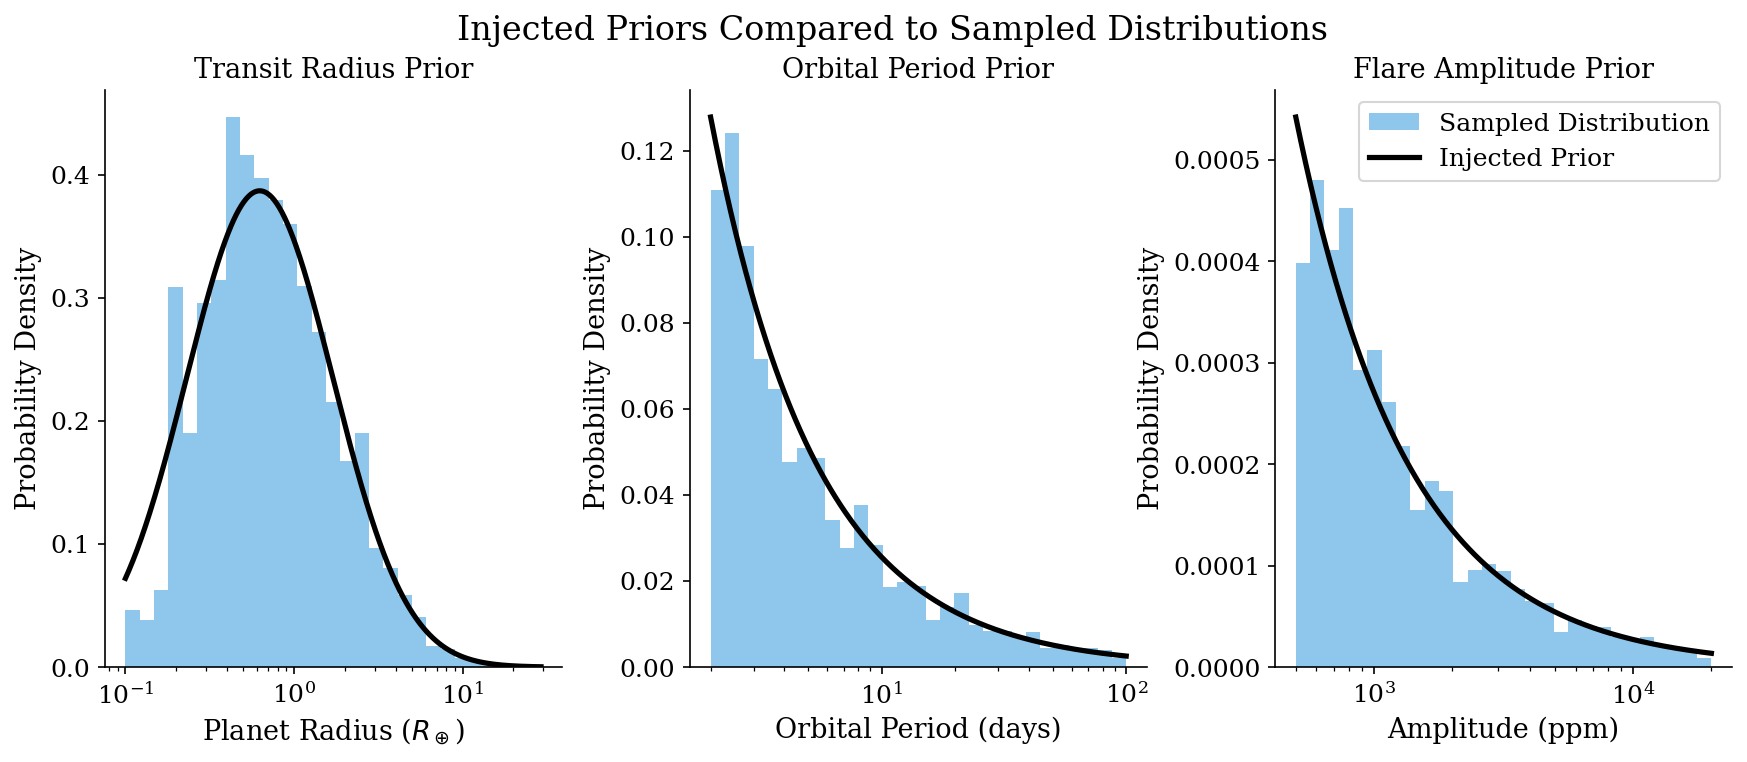

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.subplots_adjust(hspace=0.35, wspace=0.28)

theme_color = "#3498db"

csv_path = "../data/input_labels/paired_simulation_labels_combined.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Could not find {csv_path}")

df = pd.read_csv(csv_path)

flares = df[df['flare_amplitude'] > 0]
transits = df[df['transit_period'] > 0]

ax = axes[0]

data_rad = transits['transit_radius_earth']

bins_rad = np.logspace(
    np.log10(0.1),
    np.log10(data_rad.max()),
    30
)

ax.hist(
    data_rad,
    bins=bins_rad,
    density=True,
    color=theme_color,
    alpha=0.55
)

# Analytical prior
x_rad = np.logspace(np.log10(0.1), np.log10(data_rad.max()), 500)

pdf_rad = lognorm.pdf(
    x_rad,
    s=1.0,
    scale=np.exp(np.log(1.7))
)

ax.plot(
    x_rad,
    pdf_rad,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Transit Radius Prior')
ax.set_xlabel(r'Planet Radius ($R_\oplus$)')
ax.set_ylabel('Probability Density')

# ==========================================
# B. Transit Period (Log-Uniform)
# ==========================================
ax = axes[1]

data_per = transits['transit_period']

bins_per = np.logspace(np.log10(2.0), np.log10(100.0), 30)

ax.hist(
    data_per,
    bins=bins_per,
    density=True,
    color=theme_color,
    alpha=0.55
)

x_per = np.logspace(np.log10(2.0), np.log10(100.0), 500)

# Proper log-uniform PDF in linear space
pdf_per = 1.0 / (
    x_per * (np.log(100.0) - np.log(2.0))
)

ax.plot(
    x_per,
    pdf_per,
    color='black',
    linewidth=2.5
)

ax.set_xscale('log')
ax.set_title('Orbital Period Prior')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Probability Density')

# ==========================================
# C. Flare Amplitude (Log-Uniform)
# ==========================================
ax = axes[2]

data_amp = flares['flare_amplitude']

bins_amp = np.logspace(np.log10(500), np.log10(20000), 30)

ax.hist(
    data_amp,
    bins=bins_amp,
    density=True,
    color=theme_color,
    alpha=0.55,
    label='Sampled Distribution'
)

x_amp = np.logspace(np.log10(500), np.log10(20000), 500)

pdf_amp = 1.0 / (
    x_amp * (np.log(20000) - np.log(500))
)

ax.plot(
    x_amp,
    pdf_amp,
    color='black',
    linewidth=2.5,
    label='Injected Prior'
)

ax.set_xscale('log')
ax.set_title('Flare Amplitude Prior')
ax.set_xlabel('Amplitude (ppm)')
ax.set_ylabel('Probability Density')
ax.legend()


plt.suptitle(
    "Injected Priors Compared to Sampled Distributions",
    fontsize=16,
    y=0.98
)

plt.show()

---
## B. Preprocessing — Instrumental Artefact Removal

PLATO stares at a field continuously, but its cameras correct for pointing drift by
periodically slewing back to target.  Each slew creates two artefacts visible in the
raw `.dat` output from PSLS:

1. **Jump discontinuities** — sudden step changes in the flux baseline where the slew
   occurs.  The third column of the `.dat` file contains a non-zero flag at every such
   event index.

2. **Thermoelastic ramp** — a slow, smooth drift in the baseline between slews caused by
   temperature gradients in the focal-plane assembly.

Both artefacts are removed in sequence before any classifier sees the data.

### B.1 Jump Correction

```
Step 1.  Read the flag column to locate every slew index j.
Step 2.  For each j:
           median_before = median(flux[j-50 : j])
           median_after  = median(flux[j  : j+50])
           offset        = median_before − median_after
           flux[j:]     += offset          ← shift all subsequent data
```

This is a piecewise constant shift that stitches adjacent segments onto a common
baseline.  The 50-sample window (~2 minutes at 25-second cadence) is wide enough to
be robust against single-point outliers but narrow enough not to be contaminated by
a nearby transit or flare.

### B.2 Thermoelastic Ramp Correction

A Savitzky–Golay low-pass filter traces the slow baseline trend.  To make this
tractable on 500 000-point arrays:

```
Step 1.  Downsample  (take every 100th point)  →  5 000-point array.
Step 2.  Apply SG filter  (window ≈ 500 pts after scaling)  →  smooth baseline.
Step 3.  Interpolate baseline back to full resolution.
Step 4.  Subtract:  flux_detrended = flux − baseline.
```

The downsampling+interpolation trick reduces the SG computation from O(N) with a huge
window to O(N/100) with a proportionally smaller window, while preserving the
low-frequency envelope that needs to be removed.

### B.3 Output

Corrected light curves are written to `*_driftcorrected.dat` alongside the originals.
Only systems flagged as `drift != 'none'` in the metadata CSV receive this treatment;
clean systems are passed through unchanged.

### B.4 Downstream normalisation

When building the tensor cache (`cnn_dataset.pt`) the CNN loader performs two final
steps on every light curve regardless of drift:

1. **Median-centering** — subtract `np.nanmedian(flux)` so the baseline sits at 0.
2. **Uniform-grid interpolation** — resample to exactly 50 000 equally-spaced points
   via linear interpolation over normalised time $t \in [0, 1]$.

This gives both classifiers a fixed-length, zero-centred representation on a common
time axis.


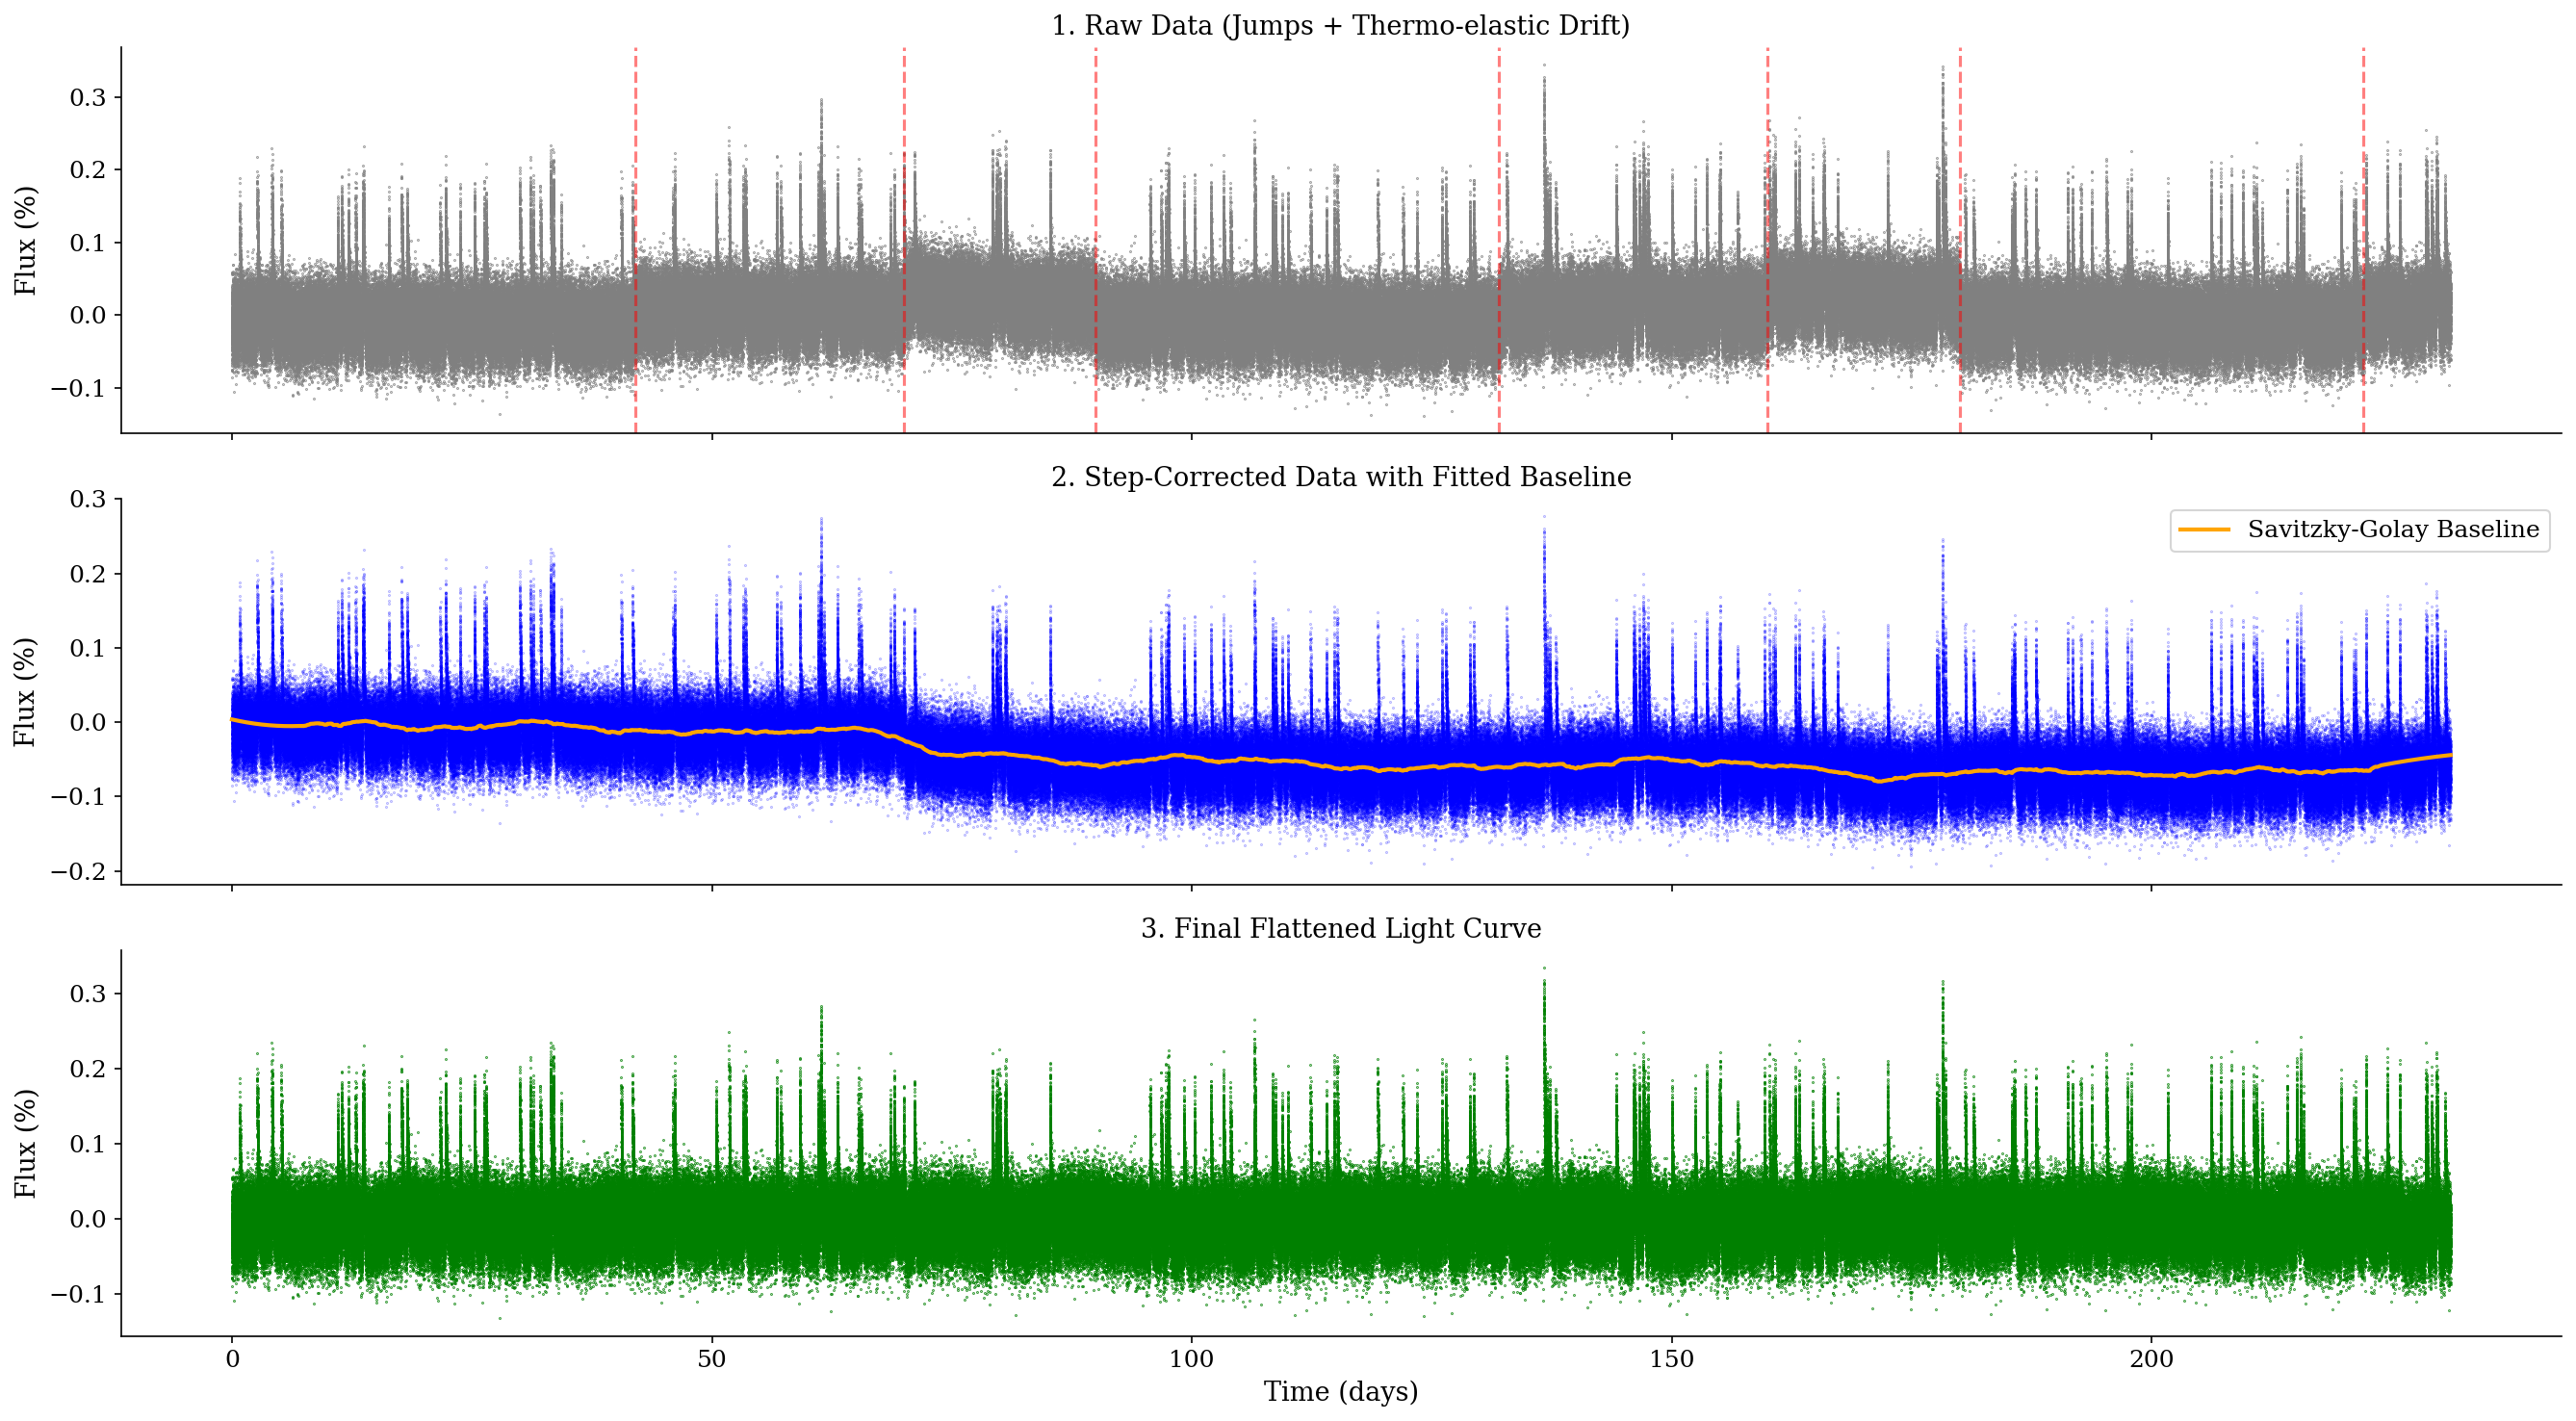

In [5]:
file_path = "../data/outputs/sys_1358/0012069449.dat"
data = np.genfromtxt(file_path)
time = data[:, 0]/60/60/24 #days
flux = data[:, 1]/1e4 #percent

# Known indices where mask updates (jumps) occur
jump_indices = [145140, 241900, 311040, 456180, 552940, 622080, 767220]

def correct_jumps(time, flux, jumps, window=50):
    """
    Aligns the baseline by calculating the median flux just before 
    and just after a known jump index, then shifting all subsequent data.
    """
    flux_corrected = flux.copy()
    
    for idx in jumps:
        # Ensure the calculation window doesn't go out of bounds
        if idx < window or idx + window > len(flux_corrected):
            continue
            
        # Calculate local medians to determine the step magnitude
        median_before = np.median(flux_corrected[idx - window : idx])
        median_after = np.median(flux_corrected[idx : idx + window])
        
        # Calculate the necessary shift to align the segments
        offset = median_before - median_after
        
        # Apply the scalar shift to the rest of the array
        flux_corrected[idx:] += offset
        
    return flux_corrected

def correct_slope(time, flux, bin_size=100, original_window=90001, polyorder=2):
    """
    Fits a low-frequency baseline instantly by downsampling the data, 
    applying the filter to the tiny array, and interpolating the curve back.
    """
    # 1. Downsample the data (e.g., take every 100th point)
    # This reduces a 500,000 point array to a 5,000 point array.
    t_down = time[::bin_size]
    f_down = flux[::bin_size]
    
    # 2. Scale down the window length appropriately
    small_window = original_window // bin_size
    if small_window % 2 == 0: 
        small_window += 1
    small_window = max(3, min(small_window, len(f_down) - 1))
    
    # 3. Apply the filter to the tiny array
    baseline_down = savgol_filter(f_down, window_length=small_window, polyorder=polyorder)
    
    # 4. Interpolate that smooth curve back up to the full-resolution time array
    baseline_full = np.interp(time, t_down, baseline_down)
    
    # 5. Flatten the full light curve
    flux_detrended = flux - baseline_full
    
    return flux_detrended, baseline_full

# 1. Apply the jump correction just like before
flux_no_jumps = correct_jumps(time, flux, jump_indices)

# 2. Apply the slope correction
flux_final, fitted_baseline = correct_slope(time, flux_no_jumps, bin_size=100, original_window=50001)

# 3. Plotting the pipeline
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Top: Raw Data
axes[0].scatter(time, flux, s=0.1, color='gray')
axes[0].set_title("1. Raw Data (Jumps + Thermo-elastic Drift)")
for j in jump_indices:
    if j < len(time):
        axes[0].axvline(time[j], color='red', linestyle='--', alpha=0.5)

axes[0].set_ylabel("Flux (%)")

# Middle: Jumps Corrected + Overlay of Slope Fit
axes[1].scatter(time, flux_no_jumps, s=0.1, color='blue', alpha=0.4)
axes[1].plot(time, fitted_baseline, color='orange', linewidth=2, label="Savitzky-Golay Baseline")
axes[1].set_title("2. Step-Corrected Data with Fitted Baseline")
axes[1].legend()
axes[1].set_ylabel("Flux (%)")

# Bottom: Fully Detrended
axes[2].scatter(time, flux_final, s=0.1, color='green')
axes[2].set_title("3. Final Flattened Light Curve")
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("Flux (%)")
plt.tight_layout()
plt.show()

---
## C. Random Forest Classifier

### C.1 Philosophy

The Random Forest reduces each 50 000-point light curve to an **11-dimensional feature
vector** using domain-knowledge-guided statistics, then trains an ensemble of decision
trees on those vectors.  The feature engineering step acts as a hand-crafted
*signal detector*: rather than learning what a transit looks like from scratch, it runs a
Box Least Squares (BLS) periodogram — the classical algorithm used in the Kepler and
TESS pipelines — and passes the detection statistic directly to the classifier.

### C.2 Feature Engineering

Features fall into three physics-motivated groups:

| Group | Feature | Physical meaning |
|-------|---------|-----------------|
| **Statistical** | `skewness` | Asymmetry — flares pull the distribution positive |
| | `kurtosis` | Heavy tails — both flares and transits increase kurtosis |
| | `neg_outlier_frac` | Fraction < −3σ — real transits create negative dips |
| **Flare** | `p99_snr` | 99th-percentile flux divided by noise σ |
| | `pos_flux_area` | Integral of positive flux over time (ppm · day) |
| | `frac_above_3sigma` | Fraction of points > 3σ above baseline |
| | `longest_3sigma_run` | Longest consecutive run above 3σ (count and days) |
| **BLS transit** | `bls_peak_power` | Peak SNR from BLS periodogram |
| | `bls_depth_ppm` | Best-fit transit depth in ppm |
| | `bls_depth_snr` | Transit depth divided by its uncertainty |

The BLS search spans:
- **160 log-spaced trial periods** from 2 to 100 days
- **4 duration candidates**: 0.08, 0.16, 0.32, 0.64 days

The noise level σ is estimated robustly as the normalised median absolute deviation
(NMAD) of first differences, which is insensitive to outliers from flares or transits.

### C.3 Model Architecture (schematic)

```
Light curve (50 000 pts)
        │
        ▼
 ┌──────────────────────────────────────────────┐
 │  FEATURE EXTRACTION  (domain-knowledge)      │
 │                                              │
 │  stats_3 ──┐                                 │
 │  flare_5 ──┼──► feature vector  (11-D)       │
 │  bls_3   ──┘                                 │
 └──────────────────────┬───────────────────────┘
                        │
                        ▼
              SimpleImputer (median)
                        │
                        ▼
         ┌──────────────────────────┐
         │  RandomForestClassifier  │
         │   n_estimators = 300     │
         │   max_depth    = None    │
         │   min_samples_leaf = 2   │
         │   class_weight = balanced│
         └───────────┬──────────────┘
                     │  300 trees vote
                     ▼
          4-class softmax probability
         {neither, flare, transit, both}
                     │
                     ▼
               argmax → predicted class
```

### C.4 Hyperparameters

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| `n_estimators` | 300 | Enough trees to stabilise OOB error |
| `max_depth` | None | Fully-grown trees; regularised by `min_samples_leaf` |
| `min_samples_leaf` | 2 | Prevents single-sample leaves; acts as mild regulariser |
| `class_weight` | `"balanced"` | Counteracts any residual class imbalance |
| `random_state` | 42 | Reproducibility |

### C.5 Key design choice — 4-class vs. multi-label

Unlike the CNN (which uses two independent sigmoid heads), the RF is trained as a
**single 4-class classifier** over {neither, flare, transit, both}.  The `both` class
must be recognised from the *combined* statistical footprint of a superimposed flare
and transit — a harder problem than the CNN's independent heads.


In [6]:
# Print RF pipeline summary
RF_MODEL = rf_clf.named_steps["model"]

print(f"Random Forest: {RF_MODEL.n_estimators} trees")
print(f"Feature count: {RF_MODEL.n_features_in_}")
print(f"Classes:       {list(RF_MODEL.classes_)}")

FEATURE_NAMES = [
    "skewness",
    "kurtosis",
    "neg_outlier_frac",
    "p99_snr",
    "pos_flux_area",
    "frac_above_3sigma",
    "longest_3sigma_run_count",
    "longest_3sigma_run_days",
    "bls_peak_power",
    "bls_depth_ppm",
    "bls_depth_snr",
]

print("\nFeature names:")
for i, name in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:2d}. {name}")


Random Forest: 300 trees
Feature count: 11
Classes:       ['both', 'flare', 'neither', 'transit']

Feature names:
   1. skewness
   2. kurtosis
   3. neg_outlier_frac
   4. p99_snr
   5. pos_flux_area
   6. frac_above_3sigma
   7. longest_3sigma_run_count
   8. longest_3sigma_run_days
   9. bls_peak_power
  10. bls_depth_ppm
  11. bls_depth_snr


---
## D. 1-D Convolutional Neural Network

### D.1 Philosophy

The CNN takes the **raw median-centred flux waveform** as input and learns feature
detectors directly from the data via backpropagation.  No hand-crafted features are
involved.  The network must simultaneously learn to recognise:

- transit morphology: a box-shaped dip with ingress/egress slopes, repeated periodically
- flare morphology: a sharp positive spike followed by an exponential decay

### D.2 Architecture

```
Input : (batch, 1, 50 000)  — raw median-centred flux
         │
         ▼
╔══════════════════════════════════════════════════════════╗
║  CONVOLUTIONAL BACKBONE                                  ║
║                                                          ║
║  Conv1d( 1→16,  k=15, pad=7) → BN → ReLU → MaxPool(4)  ║
║       length: 50 000 → 12 500                            ║
║       kernel ≈ 2 h of data (detects slope & curvature)  ║
║                    │                                     ║
║  Conv1d(16→32, k=11, pad=5) → BN → ReLU → MaxPool(4)   ║
║       length: 12 500 → 3 125                             ║
║                    │                                     ║
║  Conv1d(32→64, k=7,  pad=3) → BN → ReLU → MaxPool(4)   ║
║       length:  3 125 → 781                               ║
║                    │                                     ║
║  Conv1d(64→128,k=5,  pad=2) → BN → ReLU                 ║
║  AdaptiveMaxPool1d(16)  → (batch, 128, 16)               ║
║       translation-invariant feature map                  ║
║  Flatten → (batch, 2 048)                                ║
╚══════════════════════╦═══════════════════════════════════╝
                       │
                       ▼
         ┌─────────────────────────────┐
         │  SHARED FC HEAD             │
         │  Dropout(0.5)               │
         │  Linear(2048 → 256) → ReLU  │
         │  Dropout(0.3)               │
         │  Linear(256  →  64) → ReLU  │
         └──────────┬──────────────────┘
                    │
          ┌─────────┴──────────┐
          ▼                    ▼
  head_flare               head_transit
  Linear(64→1)             Linear(64→1)
  Sigmoid                  Sigmoid
  P(flare) ──thresh=0.50   P(transit)──thresh=0.50
          │                    │
          └─────────┬──────────┘
                    ▼
           Combine: if P_f>0.50 → has_flare
                    if P_t>0.50 → has_transit
                    → {neither, flare, transit, both}
```

### D.3 Design Choices

**Kernel sizes decrease with depth.** Early layers see a large receptive field
(k=15, ≈2 hours) to capture the broad slope of transit ingress and egress; later
layers refine over progressively shorter timescales.

**`AdaptiveMaxPool1d(16)` as the final pooling layer** compresses the time axis to a
fixed 16 positions regardless of input length, giving translation invariance.  A transit
that occurs at day 50 or day 300 produces the same feature activation.

**Dual binary heads instead of a single 4-class softmax.** Flares and transits are
*independent physical phenomena*.  Modelling them as two Bernoulli variables
(`BCEWithLogitsLoss` per head) naturally handles the `both` class without needing
explicit training examples of superimposed signals.  The threshold on the transit
head (0.28) was tuned post-training on the validation set to improve transit recall
without sacrificing too much precision.

**BatchNorm after every Conv layer** stabilises training on the wide dynamic range of
flux amplitudes (sub-100 ppm transits coexist with 20 000 ppm flares).

### D.4 Training Configuration

| Hyperparameter | Value |
|----------------|-------|
| Optimiser | Adam |
| Learning rate | 4×10⁻⁴ |
| Weight decay | 10⁻⁴ |
| Epochs | 15 |
| Batch size | 32 |
| Train/val split | 80/20, seed=42 |
| Loss (flare head) | `BCEWithLogitsLoss` |
| Loss (transit head) | `BCEWithLogitsLoss` |

### D.5 Approximate Parameter Count


In [7]:
# CNN architecture summary — printed for reference
print("LightCurveCNN Architecture")
print("=" * 55)
print("""
Input : (batch, 1, 50_000)  <-- raw median-centred flux

CONVOLUTIONAL BACKBONE
  Conv1d( 1->16,  k=15, pad=7)  BN ReLU  MaxPool1d(4)   -> 12,500
  Conv1d(16->32,  k=11, pad=5)  BN ReLU  MaxPool1d(4)   ->  3,125
  Conv1d(32->64,  k=7,  pad=3)  BN ReLU  MaxPool1d(4)   ->    781
  Conv1d(64->128, k=5,  pad=2)  BN ReLU  AdaptiveMax(16)->     16
  Flatten -> (batch, 2048)

SHARED FC
  Dropout(0.5) -> Linear(2048->256) -> ReLU
  Dropout(0.3) -> Linear(256->64)   -> ReLU

DUAL BINARY HEADS
  head_flare   : Linear(64->1) + Sigmoid  -> P(flare)    thresh=0.50
  head_transit : Linear(64->1) + Sigmoid  -> P(transit)  thresh=0.50
""")

# Approximate parameter count
APPROX_PARAMS = (
    (1 * 16 * 15) + 16 * 2
    + (16 * 32 * 11) + 32 * 2
    + (32 * 64 * 7) + 64 * 2
    + (64 * 128 * 5) + 128 * 2
    + 2048 * 256 + 256
    + 256 * 64 + 64
    + 64 * 1 + 1
    + 64 * 1 + 1
)

print(f"Approximate trainable parameters: {APPROX_PARAMS:,}")


LightCurveCNN Architecture

Input : (batch, 1, 50_000)  <-- raw median-centred flux

CONVOLUTIONAL BACKBONE
  Conv1d( 1->16,  k=15, pad=7)  BN ReLU  MaxPool1d(4)   -> 12,500
  Conv1d(16->32,  k=11, pad=5)  BN ReLU  MaxPool1d(4)   ->  3,125
  Conv1d(32->64,  k=7,  pad=3)  BN ReLU  MaxPool1d(4)   ->    781
  Conv1d(64->128, k=5,  pad=2)  BN ReLU  AdaptiveMax(16)->     16
  Flatten -> (batch, 2048)

SHARED FC
  Dropout(0.5) -> Linear(2048->256) -> ReLU
  Dropout(0.3) -> Linear(256->64)   -> ReLU

DUAL BINARY HEADS
  head_flare   : Linear(64->1) + Sigmoid  -> P(flare)    thresh=0.50
  head_transit : Linear(64->1) + Sigmoid  -> P(transit)  thresh=0.50

Approximate trainable parameters: 602,770


---
## 3. Overall Classification Performance

Classification reports for both models on the shared validation set.
Precision, recall, and F1 are computed per class; macro and weighted averages
are also shown.


In [10]:
# Map the binary flags back to strings
conditions_true = [
    (rf['true_has_flare'] == 0) & (rf['true_has_transit'] == 0),
    (rf['true_has_flare'] == 1) & (rf['true_has_transit'] == 0),
    (rf['true_has_flare'] == 0) & (rf['true_has_transit'] == 1),
    (rf['true_has_flare'] == 1) & (rf['true_has_transit'] == 1)
]

conditions_pred = [
    (rf['pred_has_flare'] == 0) & (rf['pred_has_transit'] == 0),
    (rf['pred_has_flare'] == 1) & (rf['pred_has_transit'] == 0),
    (rf['pred_has_flare'] == 0) & (rf['pred_has_transit'] == 1),
    (rf['pred_has_flare'] == 1) & (rf['pred_has_transit'] == 1)
]

# Use the exact string labels your CNN expects
choices = ['neither', 'flare', 'transit', 'both']

# Apply the text labels to the RF dataframe
rf['true_event_class'] = np.select(conditions_true, choices)
rf['pred_event_class'] = np.select(conditions_pred, choices)

# Re-extract for the classification report
y_true_rf  = rf['true_event_class']
y_pred_rf  = rf['pred_event_class']

# Now extract them just like the CNN
y_true_cnn = cnn['true_event_class']
y_pred_cnn = cnn['pred_event_class']

cnn_report_dict = classification_report(
    y_true_cnn, y_pred_cnn, labels=CLASS_ORDER, output_dict=True)
rf_report_dict = classification_report(
    y_true_rf, y_pred_rf, labels=CLASS_ORDER, output_dict=True)

print("=" * 58)
print("CNN Classification Report")
print("=" * 58)
print(classification_report(y_true_cnn, y_pred_cnn, labels=CLASS_ORDER))

print("=" * 58)
print("Random Forest Classification Report")
print("=" * 58)
print(classification_report(y_true_rf, y_pred_rf, labels=CLASS_ORDER))


CNN Classification Report
              precision    recall  f1-score   support

     neither       0.52      1.00      0.69        85
       flare       0.47      0.79      0.59        62
     transit       0.94      0.22      0.35        74
        both       0.92      0.14      0.25        76

    accuracy                           0.54       297
   macro avg       0.71      0.54      0.47       297
weighted avg       0.72      0.54      0.47       297

Random Forest Classification Report
              precision    recall  f1-score   support

     neither       0.68      0.81      0.74        85
       flare       0.53      0.58      0.55        62
     transit       0.63      0.61      0.62        74
        both       0.66      0.49      0.56        76

    accuracy                           0.63       297
   macro avg       0.63      0.62      0.62       297
weighted avg       0.63      0.63      0.62       297



### 3.1 Side-by-side comparison table

For each class: which model wins on precision? Which on recall?


In [11]:
rows = []
for cls in CLASS_ORDER + ['macro avg', 'weighted avg']:
    c = cnn_report_dict.get(cls, {})
    r = rf_report_dict.get(cls, {})

    def fmt(v):
        # Bold the better value
        return f"{v:.3f}"

    rows.append({
        'Class':          cls,
        'CNN Prec':       f"{c.get('precision', 0):.3f}",
        'RF  Prec':       f"{r.get('precision', 0):.3f}",
        'CNN Recall':     f"{c.get('recall', 0):.3f}",
        'RF  Recall':     f"{r.get('recall', 0):.3f}",
        'CNN F1':         f"{c.get('f1-score', 0):.3f}",
        'RF  F1':         f"{r.get('f1-score', 0):.3f}",
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
rf_acc  = accuracy_score(y_true_rf,  y_pred_rf)
print(f"\nOverall accuracy:  CNN = {cnn_acc:.3f}   RF = {rf_acc:.3f}   "
      f"Delta = {cnn_acc - rf_acc:+.3f}")


       Class CNN Prec RF  Prec CNN Recall RF  Recall CNN F1 RF  F1
     neither    0.521    0.676      1.000      0.812  0.685  0.738
       flare    0.467    0.529      0.790      0.581  0.587  0.554
     transit    0.941    0.634      0.216      0.608  0.352  0.621
        both    0.917    0.661      0.145      0.487  0.250  0.561
   macro avg    0.711    0.625      0.538      0.622  0.468  0.618
weighted avg    0.716    0.631      0.542      0.630  0.470  0.625

Overall accuracy:  CNN = 0.542   RF = 0.630   Delta = -0.088


---
## 4. Confusion Matrices

Normalised by true class (rows sum to 1). The diagonal shows per-class recall.
Off-diagonal cells reveal systematic confusion patterns — e.g. whether the model
confuses `transit` with `neither` (missed detections) or with `flare` (false positives
of the wrong type).


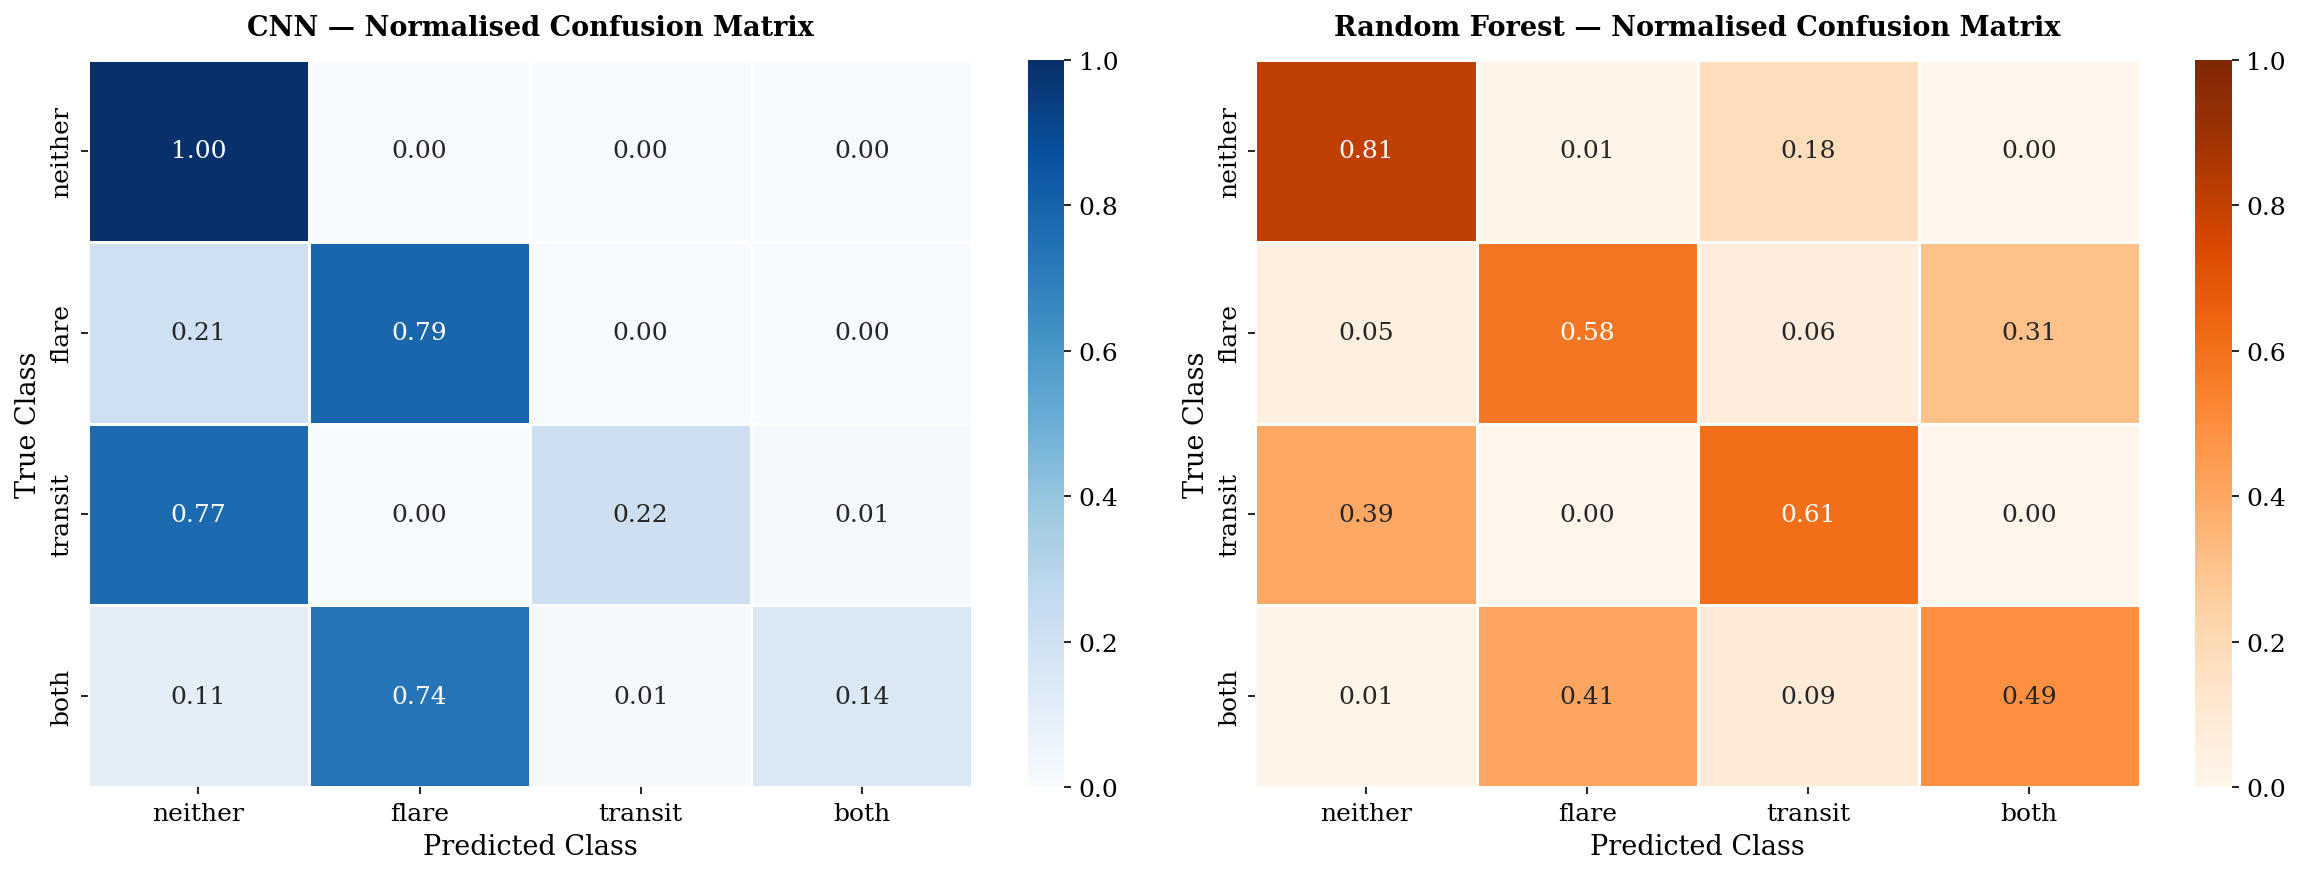

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_true, y_pred, title, cmap in [
    (axes[0], y_true_cnn, y_pred_cnn, "CNN",           "Blues"),
    (axes[1], y_true_rf,  y_pred_rf,  "Random Forest", "Oranges"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap=cmap,
        xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
        ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
        annot_kws={"size": 12}
    )
    ax.set_title(f"{title} — Normalised Confusion Matrix", fontweight='bold', pad=12)
    ax.set_ylabel("True Class")
    ax.set_xlabel("Predicted Class")

plt.tight_layout()
plt.savefig("img/comparison_confusion_matrices.pdf", bbox_inches='tight')
plt.show()


---
## 5. Detection Efficiency vs. Physical Parameters

The most astrophysically meaningful diagnostic: *how does detection probability
change as a function of the injected signal properties?*

A good classifier should:
- Approach P(detection) ≈ 1 for strong signals (large planets, bright flares)
- Have a well-defined sensitivity threshold below which detection fails
- Ideally, this threshold should be as low as possible

Both models are overlaid on the same axes so the sensitivity limits can be
read off directly.


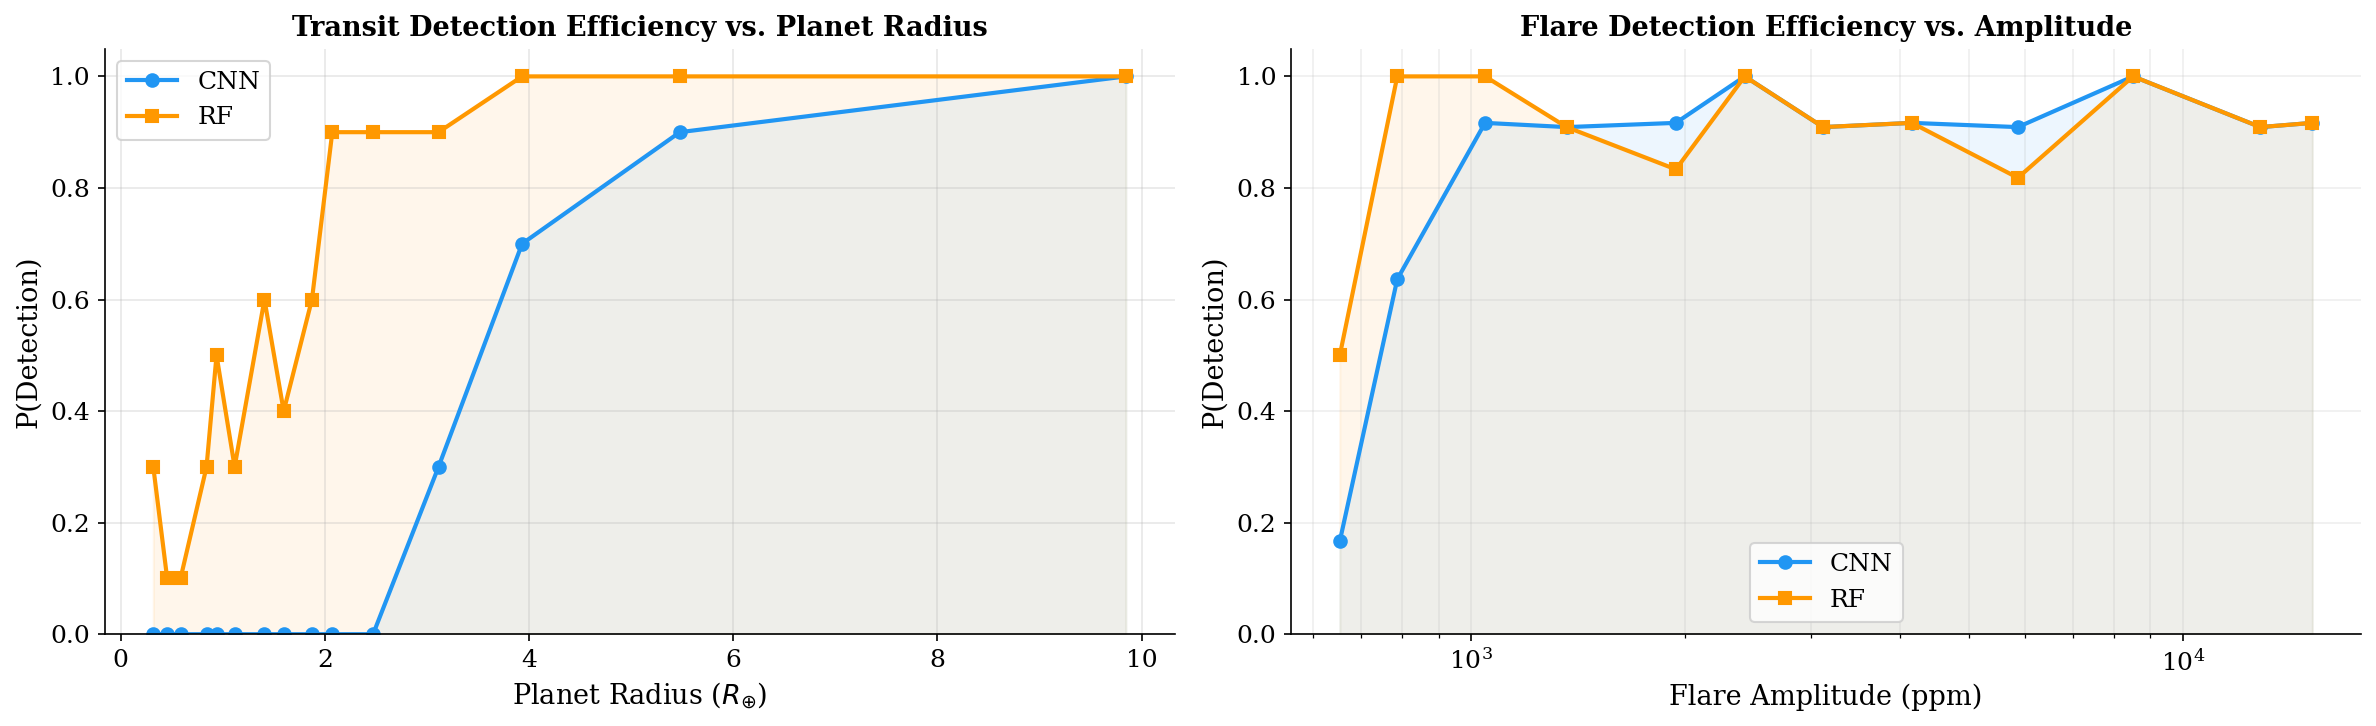

In [13]:
def detection_curve(df, feature_col, event_type='transit', bins=15):
    """
    Compute binned detection probability as a function of a physical parameter.
    Returns (midpoints, probabilities, counts).
    'Detection' means the model correctly identified the event *component*,
    regardless of the other class label.  e.g. a 'both' system counts as a
    transit detection if the model predicts 'transit' or 'both'.
    """
    valid = [event_type, 'both']
    subset = df[df['true_event_class'].isin(valid)].dropna(subset=[feature_col]).copy()
    subset['detected'] = subset['pred_event_class'].isin(valid).astype(int)

    try:
        subset['bin'] = pd.qcut(subset[feature_col], q=bins, duplicates='drop')
    except ValueError:
        subset['bin'] = pd.cut(subset[feature_col], bins=bins)

    stats = subset.groupby('bin', observed=True).agg(
        prob=('detected', 'mean'),
        mid=(feature_col, 'median'),
        count=('detected', 'count')
    ).dropna()

    return stats['mid'].values, stats['prob'].values, stats['count'].values


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Transit vs. planet radius ─────────────────────────────────────────────
ax = axes[0]
for df, color, label, marker in [
    (cnn, CNN_COLOR, 'CNN', 'o'),
    (rf,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'transit_radius_earth', 'transit', bins=15)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel(r"Planet Radius ($R_{\oplus}$)")
ax.set_ylabel("P(Detection)")
ax.set_title("Transit Detection Efficiency vs. Planet Radius", fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Flare vs. amplitude ───────────────────────────────────────────────────
ax = axes[1]
for df, color, label, marker in [
    (cnn, CNN_COLOR, 'CNN', 'o'),
    (rf,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'flare_amplitude', 'flare', bins=12)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel("Flare Amplitude (ppm)")
ax.set_ylabel("P(Detection)")
ax.set_title("Flare Detection Efficiency vs. Amplitude", fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("img/comparison_detection_efficiency.pdf", bbox_inches='tight')
plt.show()


---
## 6. Robustness to Instrumental Drift

PLATO introduces systematic drift at five severity levels. The preprocessing
pipeline corrects for jumps and slow thermoelastic ramps, but residuals remain
at higher drift levels. This section tests how gracefully each model degrades
as the systematics worsen.

- **none**: clean synthetic photometry, no drift injected
- **low / medium / high / max**: increasing levels of thermoelastic drift from PSLS

The key question: is one model more or less sensitive to systematics than the other?


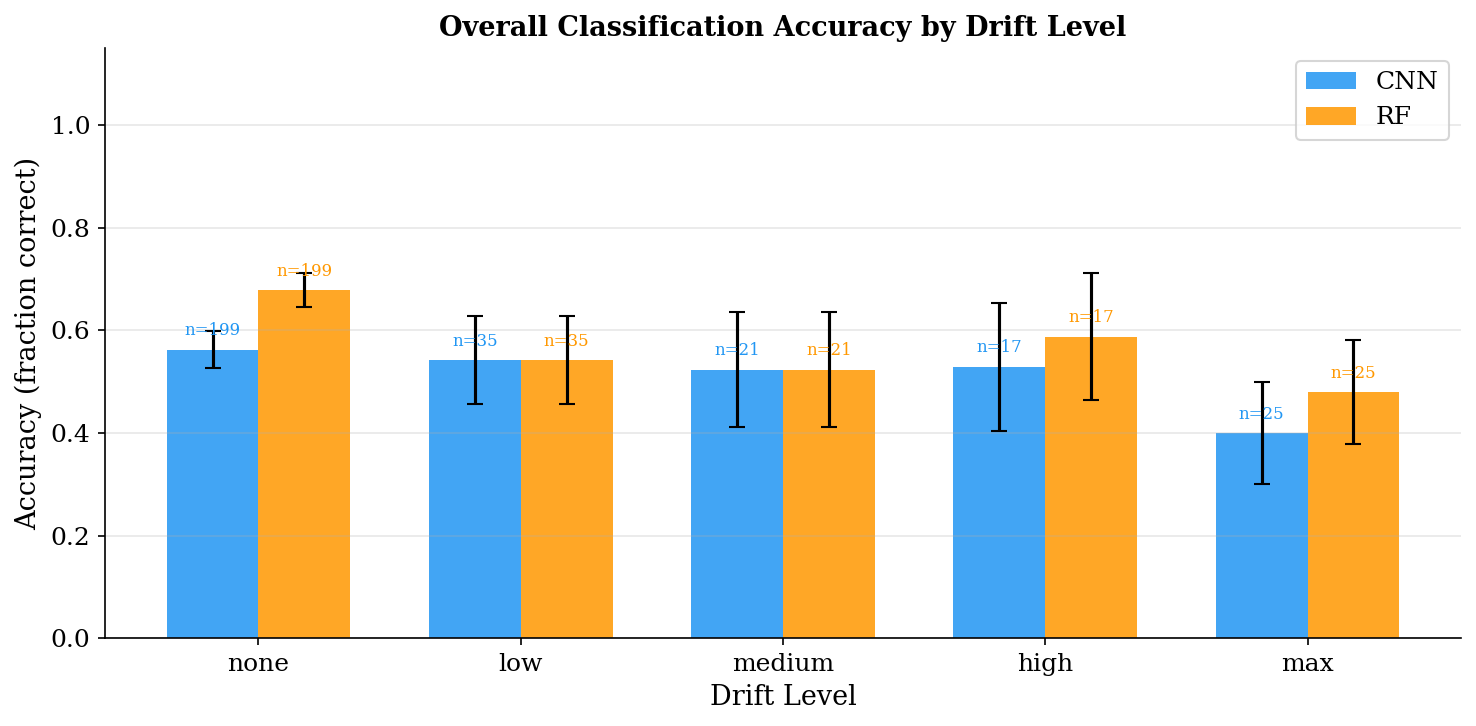

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.35
x = np.arange(len(DRIFT_ORDER))

for i, (df, color, label) in enumerate([
    (cnn, CNN_COLOR, 'CNN'),
    (rf,  RF_COLOR,  'RF'),
]):
    df = df.copy()
    df['correct'] = (df['pred_event_class'] == df['true_event_class']).astype(int)
    stats = (df.groupby('drift', observed=True)['correct']
               .agg(['mean', 'sem', 'count'])
               .reindex(DRIFT_ORDER))

    offset = (i - 0.5) * bar_width
    bars = ax.bar(x + offset, stats['mean'], width=bar_width,
                  color=color, label=label, alpha=0.85)
    ax.errorbar(x + offset, stats['mean'], yerr=stats['sem'],
                fmt='none', color='black', capsize=4, linewidth=1.5)

    # Annotate with n
    for j, (mean, n) in enumerate(zip(stats['mean'], stats['count'])):
        ax.text(x[j] + offset, mean + 0.02, f"n={int(n)}",
                ha='center', va='bottom', fontsize=8, color=color)

ax.set_xticks(x)
ax.set_xticklabels(DRIFT_ORDER)
ax.set_xlabel("Drift Level")
ax.set_ylabel("Accuracy (fraction correct)")
ax.set_title("Overall Classification Accuracy by Drift Level", fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("img/comparison_drift_accuracy.pdf", bbox_inches='tight')
plt.show()


---
## 7. Intrinsic Sensitivity — No Drift

Restricting to `drift = 'none'` isolates each model's **intrinsic sensitivity**
from the confounding effect of instrumental systematics. These curves represent
the best achievable performance on clean data, and set a ceiling for what improved
drift correction could recover.

Comparing §5 (all drift levels) vs. §7 (no drift) also quantifies how much
performance the drift is actually costing each model.


No-drift systems: CNN val = 199, RF val = 199


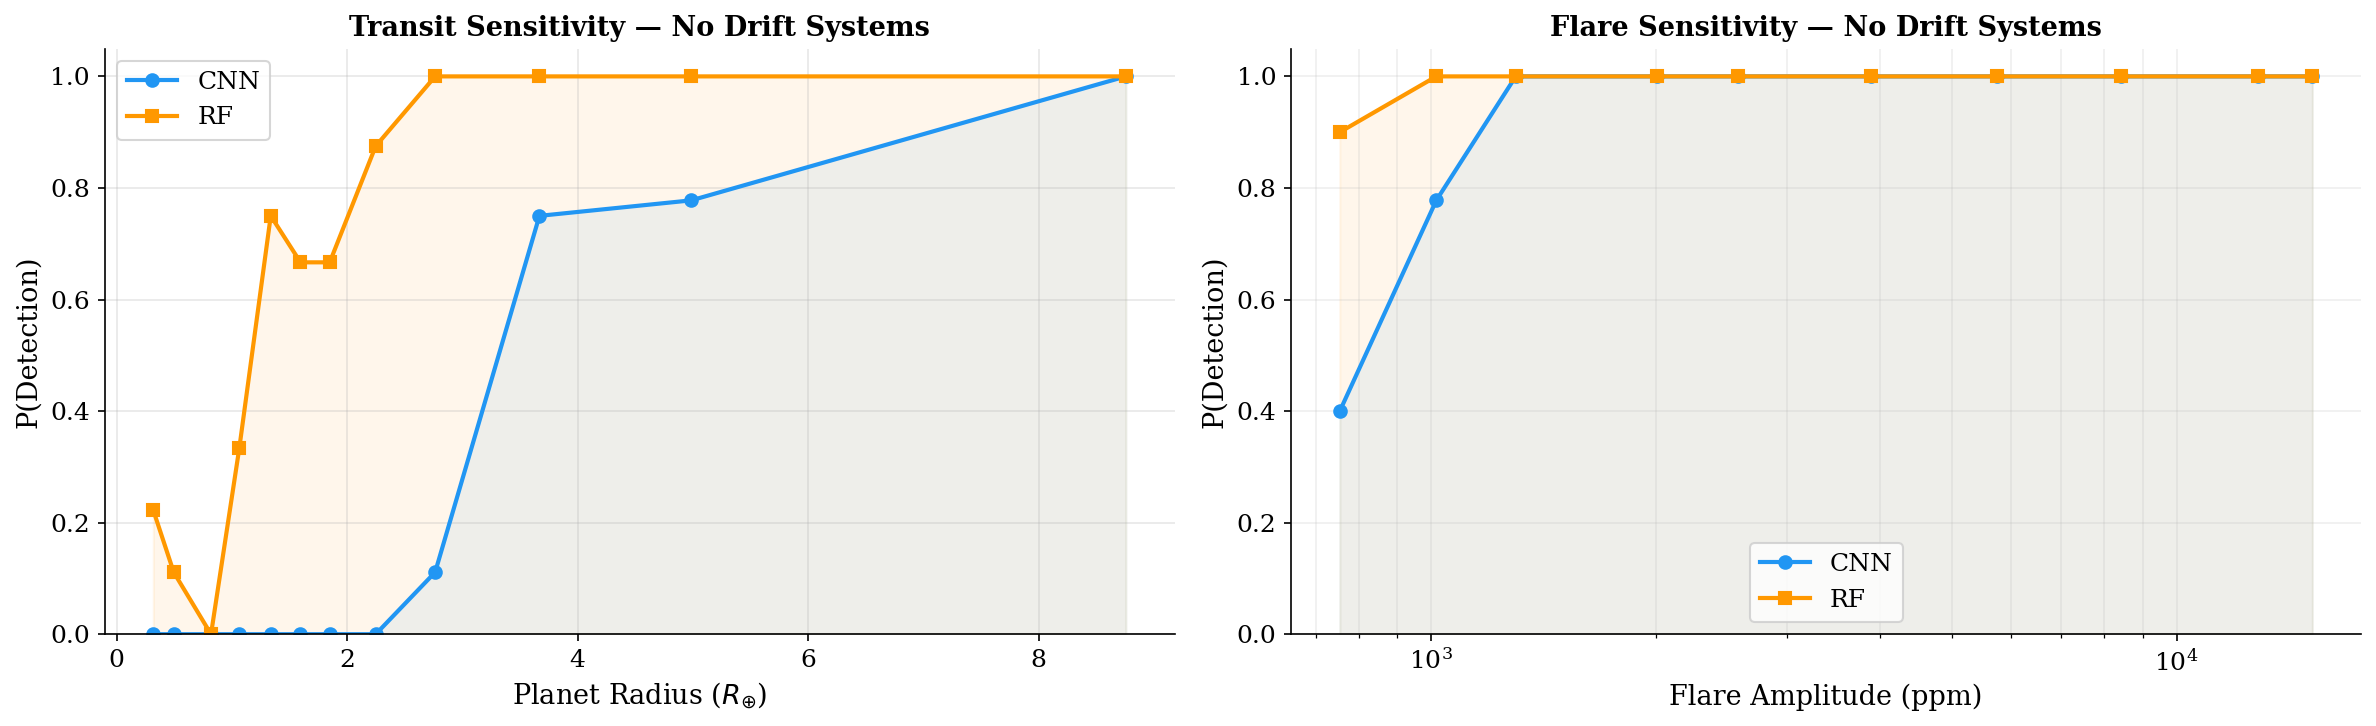

In [ ]:
cnn_clean = cnn[cnn['drift'] == 'none'].copy()
rf_clean  = rf[rf['drift'] == 'none'].copy()

print(f"No-drift systems: CNN val = {len(cnn_clean)}, RF val = {len(rf_clean)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Transit ───────────────────────────────────────────────────────────────
ax = axes[0]
for df, color, label, marker in [
    (cnn_clean, CNN_COLOR, 'CNN', 'o'),
    (rf_clean,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'transit_radius_earth', 'transit', bins=12)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel(r"Planet Radius ($R_{\oplus}$)")
ax.set_ylabel("P(Detection)")
ax.set_title("Transit Sensitivity — No Drift Systems", fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Flare ─────────────────────────────────────────────────────────────────
ax = axes[1]
for df, color, label, marker in [
    (cnn_clean, CNN_COLOR, 'CNN', 'o'),
    (rf_clean,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'flare_amplitude', 'flare', bins=10)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel("Flare Amplitude (ppm)")
ax.set_ylabel("P(Detection)")
ax.set_title("Flare Sensitivity — No Drift Systems", fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("img/comparison_nodrift_sensitivity.pdf", bbox_inches='tight')
plt.show()


---
## 8. The "Both" Class — Simultaneous Flare + Transit

The `both` class is the hardest: the classifier must simultaneously detect two
morphologically distinct signals superimposed in a single light curve. The two
architectures approach this differently:

- **CNN**: two independent binary heads, so a "both" prediction arises naturally
  whenever *both* `head_flare > 0.5` and `head_transit > 0.28`. The heads are
  free to fire independently.
- **RF**: the `both` class is a single leaf in the tree ensemble. The model must
  recognise the combined statistical signature of a flare and a transit, which
  reduces the effective sample size for this class.

For each model, we show what fraction of true `both` systems are assigned to each
predicted class. Ideally the bar for `both` would be 1.0.


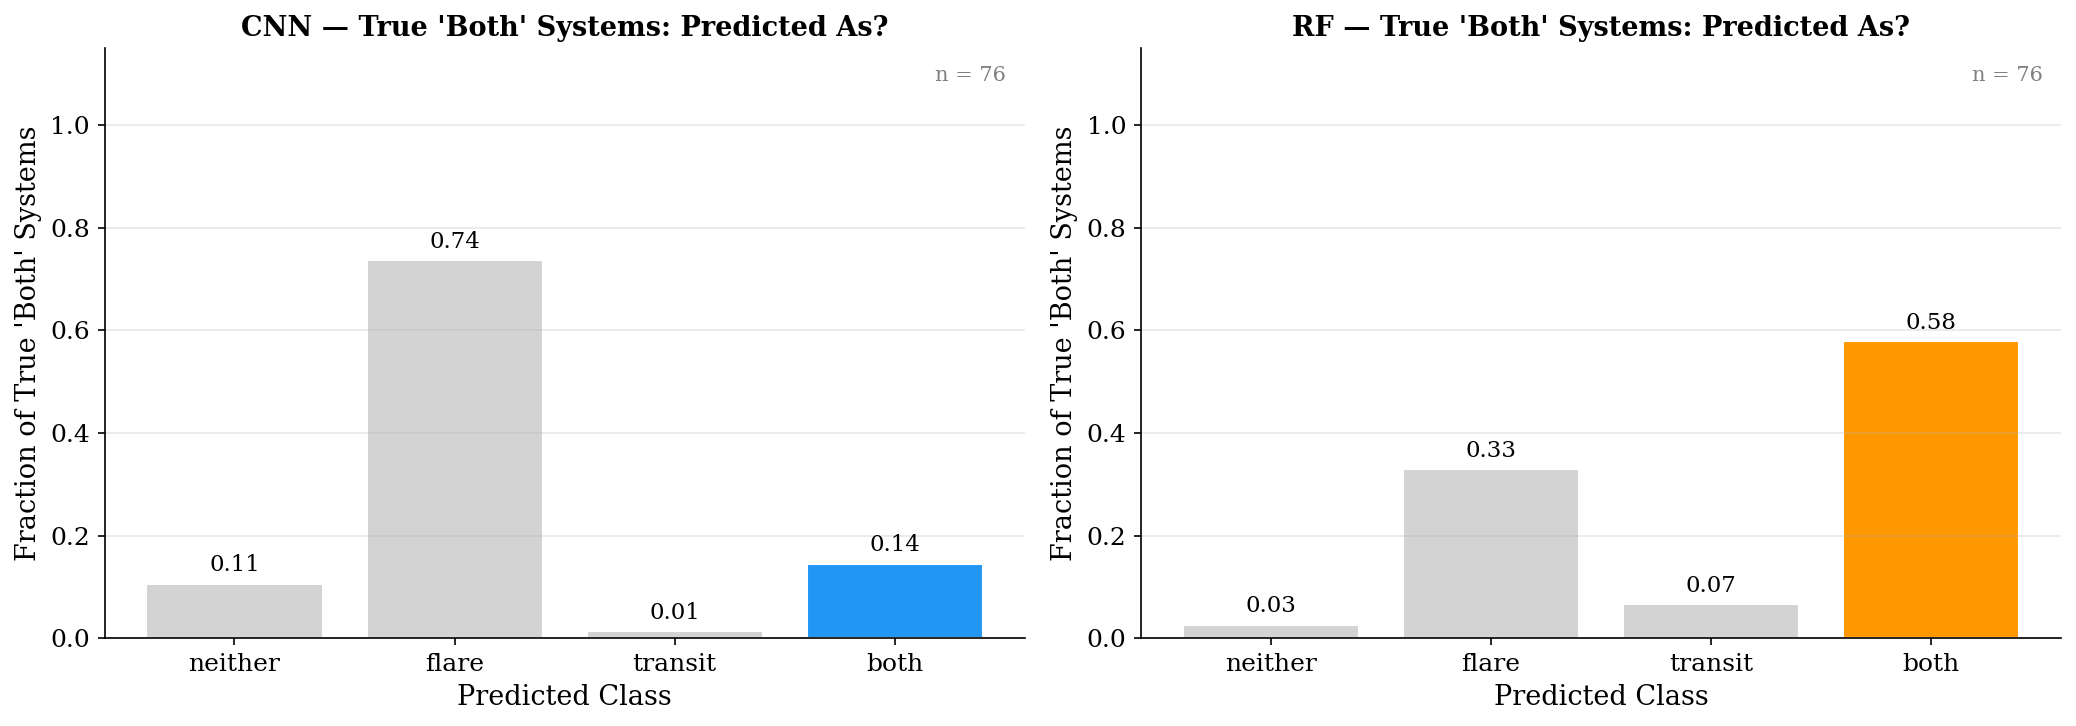

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], cnn, 'CNN', CNN_COLOR),
    (axes[1], rf,  'RF',  RF_COLOR),
]:
    both_true = df[df['true_event_class'] == 'both']
    counts    = both_true['pred_event_class'].value_counts().reindex(CLASS_ORDER, fill_value=0)
    fractions = counts / len(both_true)

    bar_colors = [color if cls == 'both' else 'lightgrey' for cls in CLASS_ORDER]
    bars = ax.bar(CLASS_ORDER, fractions.values, color=bar_colors, edgecolor='white')

    for bar, val in zip(bars, fractions.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{val:.2f}", ha='center', va='bottom', fontsize=11)

    ax.set_title(f"{label} — True 'Both' Systems: Predicted As?", fontweight='bold')
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Fraction of True 'Both' Systems")
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.98, 0.97, f"n = {len(both_true)}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig("img/comparison_both_class.pdf", bbox_inches='tight')
plt.show()


---
## 9. Output Score Distributions

Score distributions reveal how *confident* each model is and how well-separated
the positive and negative classes are in probability space.

- A well-calibrated model pushes scores toward 0 and 1, with minimal mass near 0.5.
- Significant overlap between the positive and negative distributions near the
  threshold indicates the model is uncertain for those cases — often the
  physically challenging ones (small planets, faint flares).

### 9.1 CNN — per-head sigmoid probabilities


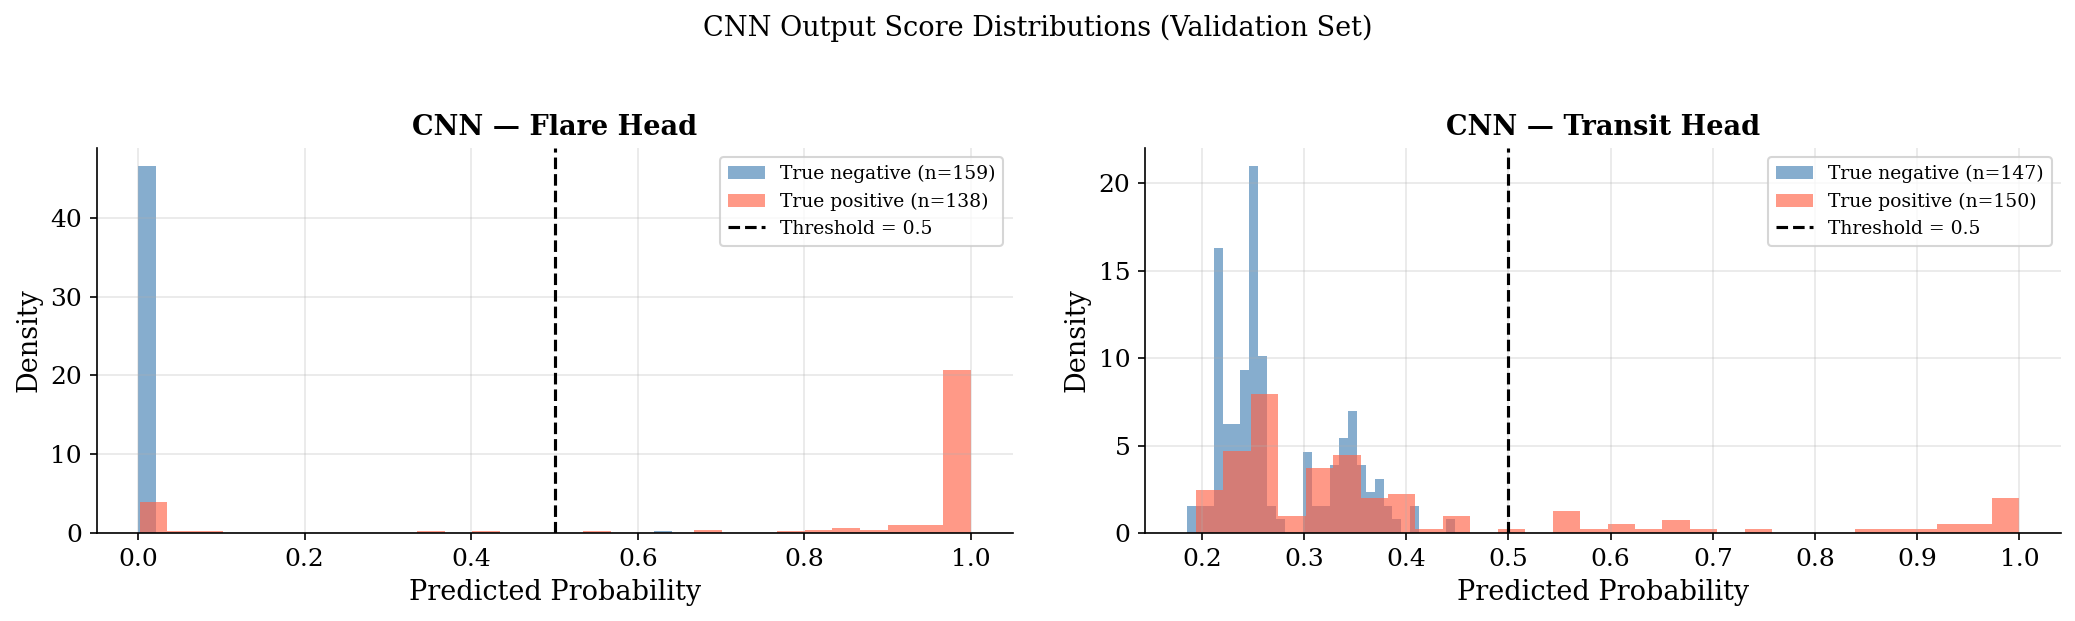

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, prob_col, true_col, title, thresh in [
    (axes[0], 'flare_prob',   'label_has_flares',  'Flare',   0.50),
    (axes[1], 'transit_prob', 'label_has_transit', 'Transit', 0.50),
]:
    pos = cnn[cnn[true_col] == 1][prob_col].dropna()
    neg = cnn[cnn[true_col] == 0][prob_col].dropna()

    ax.hist(neg, bins=30, alpha=0.65, color='steelblue',
            label=f'True negative (n={len(neg)})', density=True)
    ax.hist(pos, bins=30, alpha=0.65, color='tomato',
            label=f'True positive (n={len(pos)})', density=True)
    ax.axvline(thresh, color='black', linestyle='--',
               linewidth=1.5, label=f'Threshold = {thresh}')

    ax.set_title(f"CNN — {title}", fontweight='bold')
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("CNN Output Score Distributions (Validation Set)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("img/cnn_score_distributions.pdf", bbox_inches='tight')
plt.show()


### 9.2 Random Forest — per-class softmax probabilities


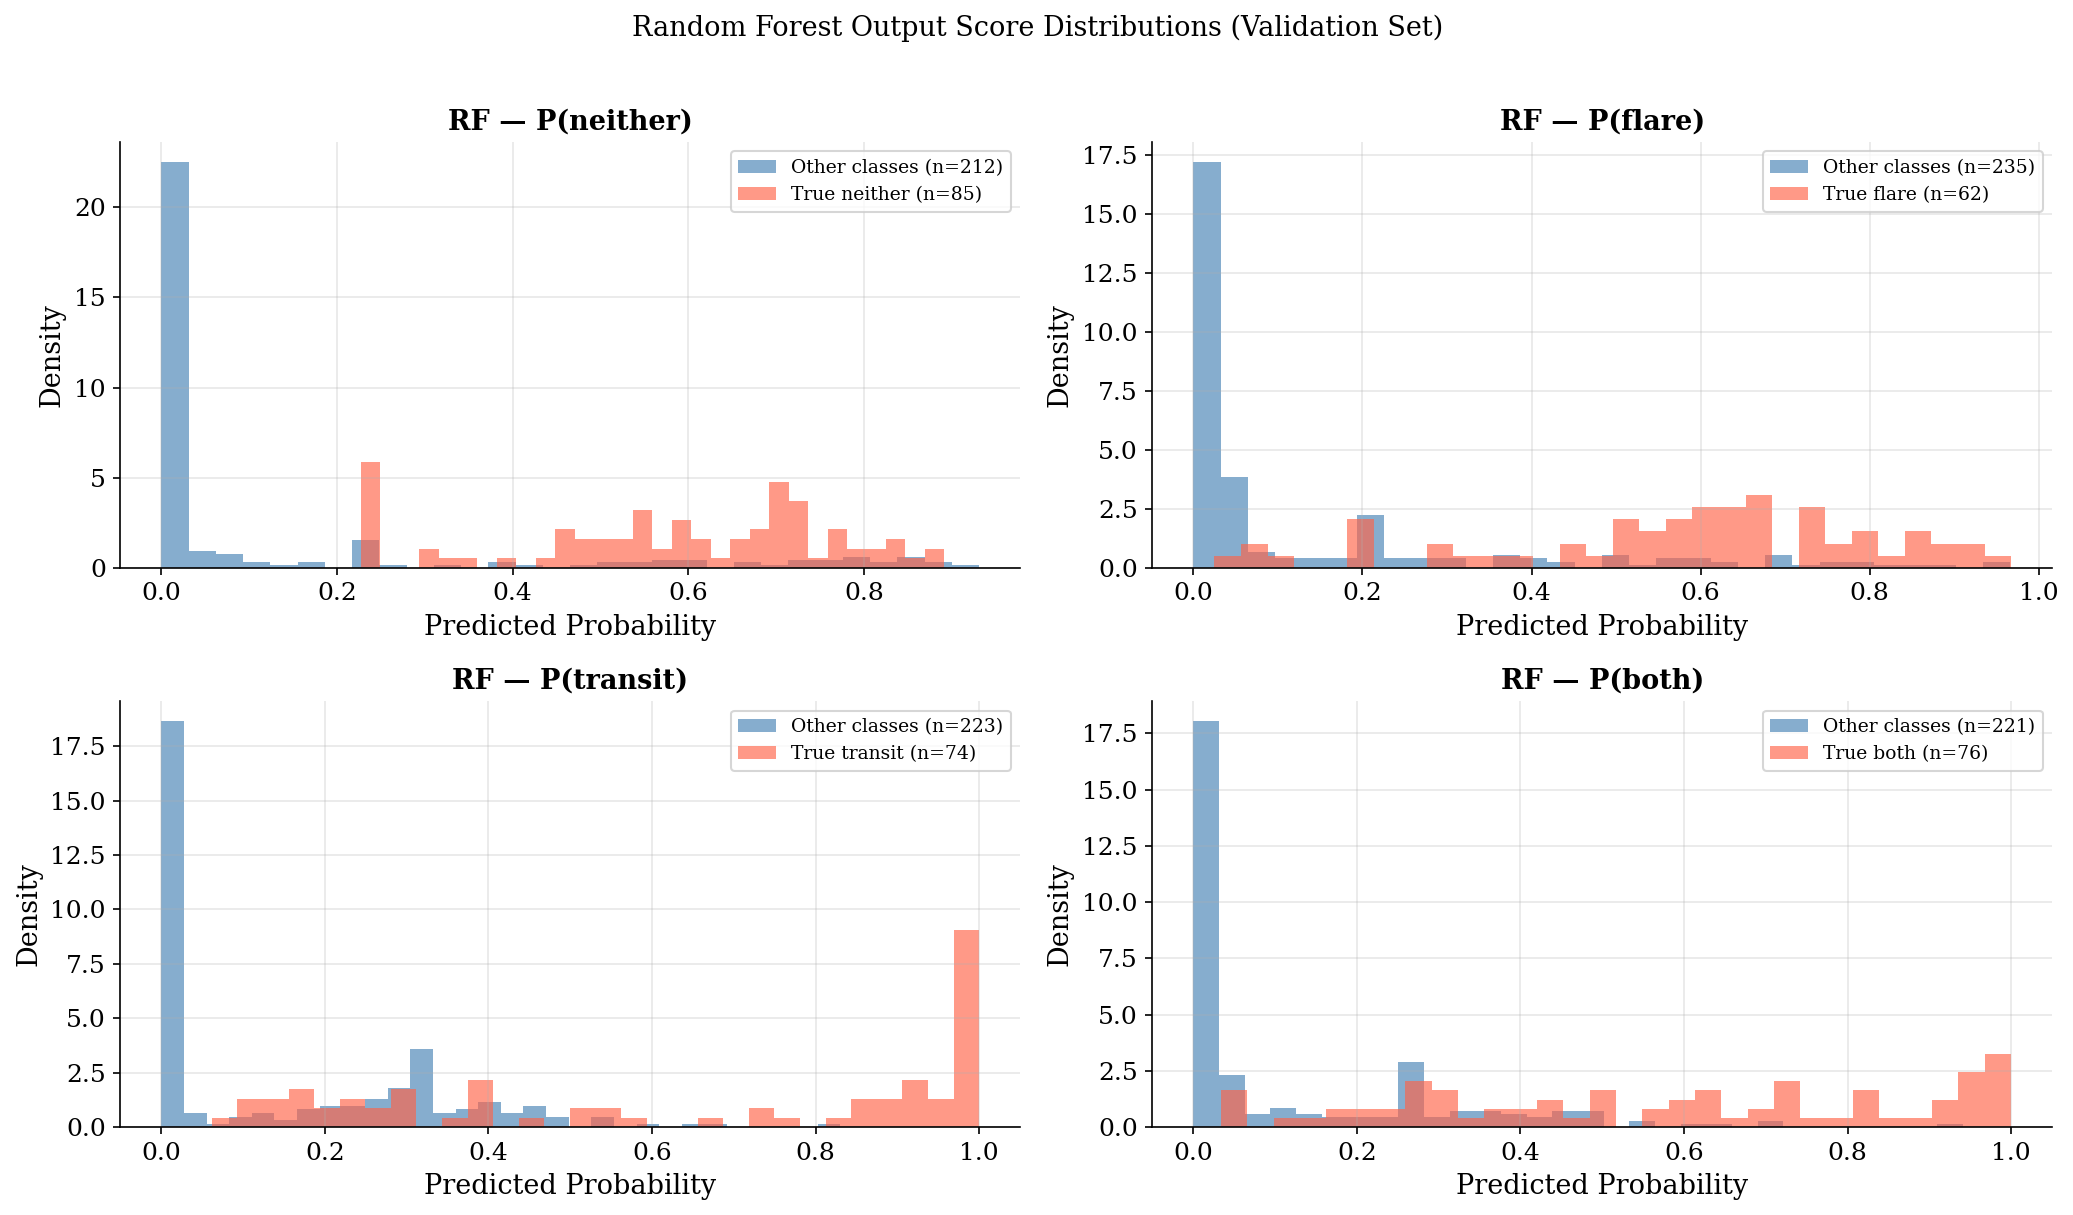

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_ORDER):
    prob_col = f"p_{cls}"
    is_true  = rf['true_event_class'] == cls

    ax.hist(rf.loc[~is_true, prob_col], bins=30, alpha=0.65, color='steelblue',
            label=f'Other classes (n={(~is_true).sum()})', density=True)
    ax.hist(rf.loc[is_true,  prob_col], bins=30, alpha=0.65, color='tomato',
            label=f'True {cls} (n={is_true.sum()})', density=True)

    ax.set_title(f"RF — P({cls})", fontweight='bold')
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Random Forest Output Score Distributions (Validation Set)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("img/rf_score_distributions.pdf", bbox_inches='tight')
plt.show()


---
## 10. Random Forest Feature Importance

Gini importance (mean decrease in impurity) shows which hand-crafted features
drive the RF's decisions. This has two uses:

1. **Validates the feature engineering**: if BLS power dominates for transit
   classification, the explicit periodicity search is genuinely useful.
2. **Illuminates what the CNN might be learning**: if the RF's most important
   transit features are BLS-derived, the CNN must learn an equivalent detector
   implicitly through its convolutional filters.

Features that are important for *all* classes will be near the top; class-specific
diagnostics may be less obvious here since importance is averaged over all splits.


Feature names:
   1. skew
   2. kurtosis
   3. negative_outlier_fraction
   4. flare_p99_snr
   5. flare_positive_area_ppm_day
   6. flare_positive_fraction_3sigma
   7. flare_longest_run_3sigma
   8. flare_longest_duration_3sigma_days
   9. bls_power
  10. bls_depth_ppm
  11. bls_depth_snr


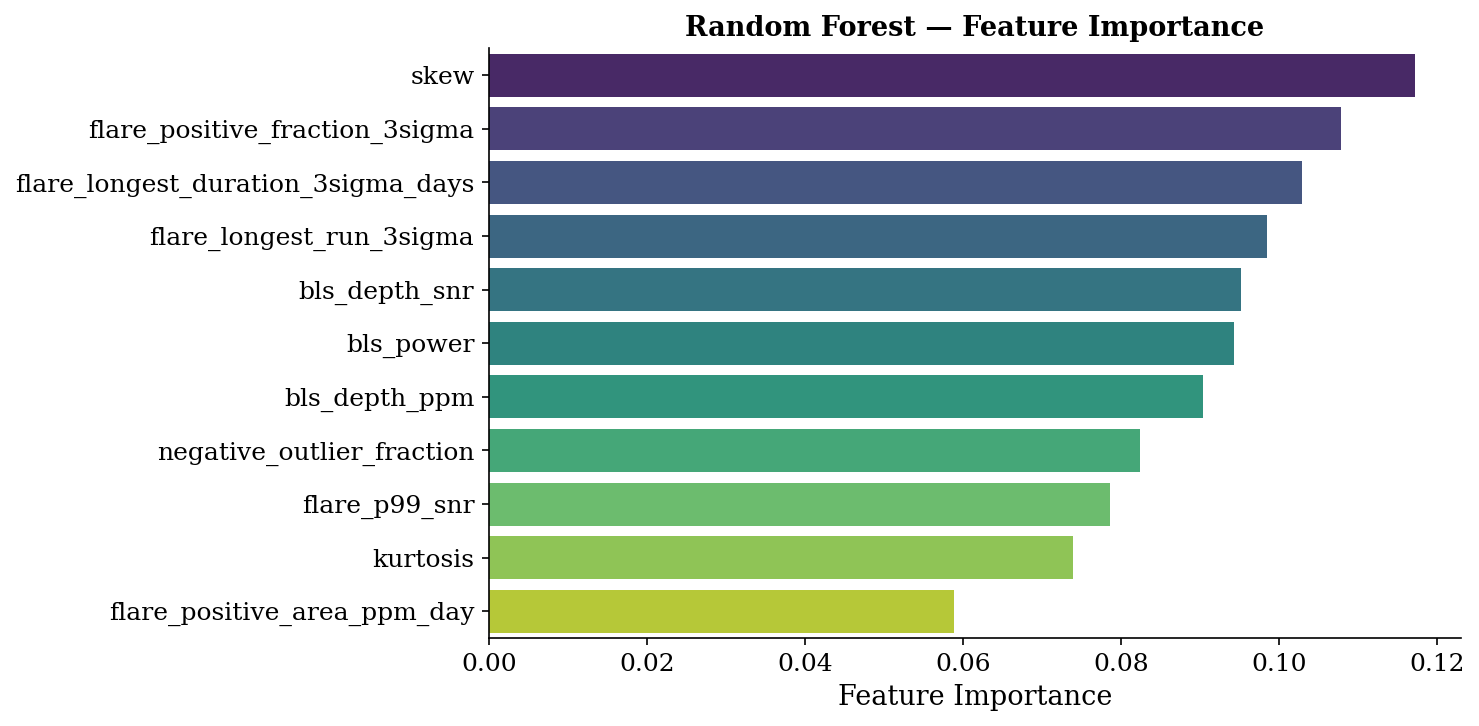


Ranked features:
                           feature  importance
                              skew    0.117161
    flare_positive_fraction_3sigma    0.107812
flare_longest_duration_3sigma_days    0.102947
          flare_longest_run_3sigma    0.098499
                     bls_depth_snr    0.095176
                         bls_power    0.094259
                     bls_depth_ppm    0.090391
         negative_outlier_fraction    0.082448
                     flare_p99_snr    0.078536
                          kurtosis    0.073893
       flare_positive_area_ppm_day    0.058877


In [ ]:
rf_model    = rf_clf.named_steps['model']
importances = rf_model.feature_importances_

try:
    with open("../data/models/feature_columns.txt", "r") as f:
        feat_names = [line.strip() for line in f if line.strip()]
except FileNotFoundError:
    print("Warning: feature_columns.txt not found. Falling back to default indices.")
    feat_names = [f"feature_{i}" for i in range(rf_model.n_features_in_)]

print(f"Feature names:")
for i, name in enumerate(feat_names, 1):
    print(f"  {i:2d}. {name}")

feat_imp = (pd.DataFrame({'feature': feat_names, 'importance': importances})
              .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(10, max(5, len(feat_names) * 0.4)))
sns.barplot(data=feat_imp, x='importance', y='feature',
            hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title("Random Forest — Feature Importance", fontweight='bold')
ax.set_xlabel("Feature Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("img/rf_feature_importance.pdf", bbox_inches='tight')
plt.show()

print("\nRanked features:")
print(feat_imp.to_string(index=False))


---
## 11. Head-to-Head Summary

A single consolidated table capturing every key metric. Delta = CNN − RF, so
positive values favour the CNN.


In [ ]:
def component_recall(df, event_type):
    """Fraction of true event_type systems where the model detected the component."""
    true_pos = df[df['true_event_class'].isin([event_type, 'both'])]
    detected = true_pos['pred_event_class'].isin([event_type, 'both'])
    return detected.mean()

rows = []

# Overall accuracy
cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
rf_acc  = accuracy_score(y_true_rf,  y_pred_rf)
rows.append({'Metric': 'Overall accuracy',
             'CNN': f"{cnn_acc:.3f}", 'RF': f"{rf_acc:.3f}",
             'Delta': f"{cnn_acc - rf_acc:+.3f}"})

# Macro F1
cnn_mf1 = f1_score(y_true_cnn, y_pred_cnn, average='macro', labels=CLASS_ORDER)
rf_mf1  = f1_score(y_true_rf,  y_pred_rf,  average='macro', labels=CLASS_ORDER)
rows.append({'Metric': 'Macro F1',
             'CNN': f"{cnn_mf1:.3f}", 'RF': f"{rf_mf1:.3f}",
             'Delta': f"{cnn_mf1 - rf_mf1:+.3f}"})

# Per-class F1
for cls in CLASS_ORDER:
    c = f1_score(y_true_cnn, y_pred_cnn, labels=[cls], average='macro')
    r = f1_score(y_true_rf,  y_pred_rf,  labels=[cls], average='macro')
    rows.append({'Metric': f"F1 — {cls}",
                 'CNN': f"{c:.3f}", 'RF': f"{r:.3f}",
                 'Delta': f"{c - r:+.3f}"})

# Transit and flare component recall
for event in ['transit', 'flare']:
    c = component_recall(cnn, event)
    r = component_recall(rf,  event)
    rows.append({'Metric': f"{event.capitalize()} component recall",
                 'CNN': f"{c:.3f}", 'RF': f"{r:.3f}",
                 'Delta': f"{c - r:+.3f}"})

# Accuracy drop from no-drift to max-drift
for df, label in [(cnn, 'CNN'), (rf, 'RF')]:
    df2 = df.copy()
    df2['correct'] = (df2['pred_event_class'] == df2['true_event_class']).astype(int)
    by_drift = df2.groupby('drift')['correct'].mean()
    drop = by_drift.get('none', np.nan) - by_drift.get('max', np.nan)
    if label == 'CNN':
        cnn_drop = drop
    else:
        rf_drop = drop

rows.append({'Metric': 'Accuracy drop: none -> max drift',
             'CNN': f"{cnn_drop:.3f}", 'RF': f"{rf_drop:.3f}",
             'Delta': f"{cnn_drop - rf_drop:+.3f}"})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print("\nDelta = CNN - RF  (positive = CNN wins, negative = RF wins)")


                          Metric   CNN    RF  Delta
                Overall accuracy 0.542 0.684 -0.141
                        Macro F1 0.468 0.682 -0.213
                    F1 — neither 0.685 0.721 -0.036
                      F1 — flare 0.587 0.692 -0.105
                    F1 — transit 0.352 0.631 -0.279
                       F1 — both 0.250 0.682 -0.432
        Transit component recall 0.193 0.640 -0.447
          Flare component recall 0.841 0.899 -0.058
Accuracy drop: none -> max drift 0.163 0.239 -0.076

Delta = CNN - RF  (positive = CNN wins, negative = RF wins)


Total missed transits (CNN): 121
Showing the 10 lowest-probability misses:\n
system_id true_event_class pred_event_class  transit_radius_earth  transit_period  transit_prob
 sys_1333             both          neither              0.449901        7.787177      0.193990
 sys_0869             both          neither              0.866060       32.970330      0.202268
 sys_1382          transit          neither              1.139061       35.171970      0.211688
 sys_1439             both          neither              0.780005       41.721111      0.216230
 sys_1452          transit          neither              0.969064        4.897083      0.216230
 sys_1467             both          neither              0.909515       12.815431      0.216230
 sys_1485             both          neither              3.050340       34.924079      0.216230
 sys_1486          transit          neither              1.198639       49.566512      0.216230
 sys_1455             both          neither              2.

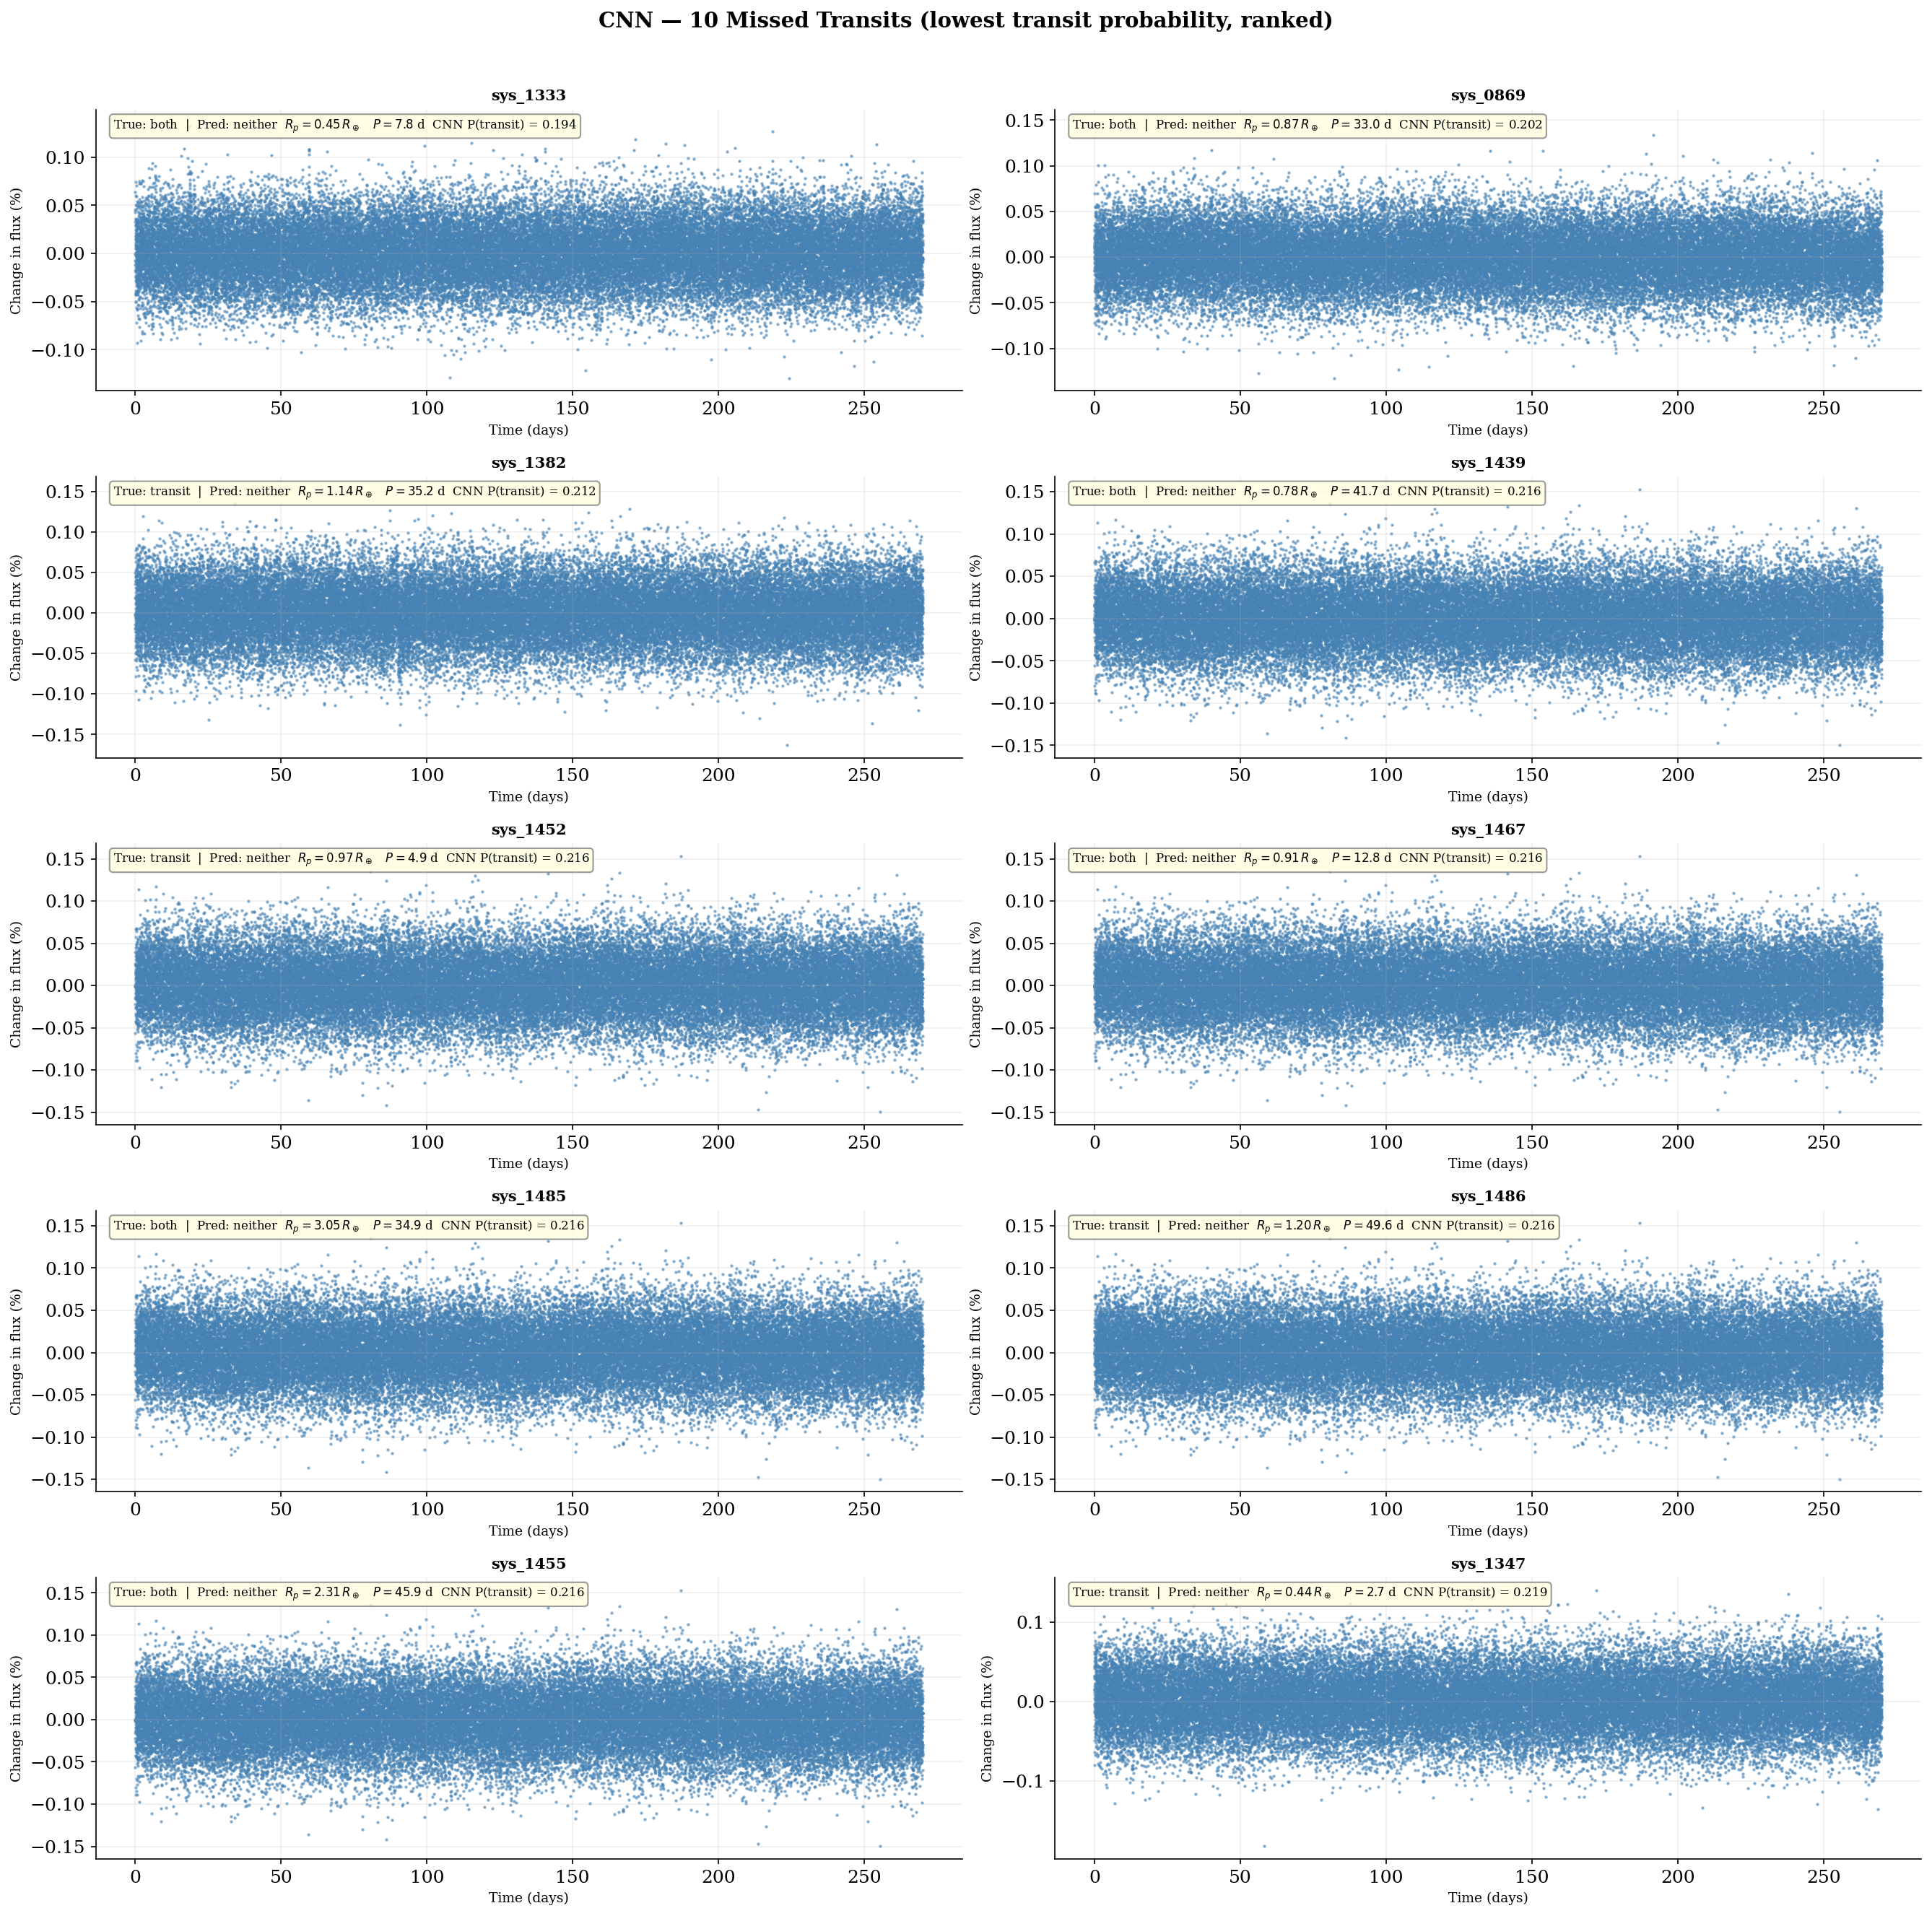

In [ ]:
# ── Identify missed transits (CNN) ────────────────────────────────────────
TRANSIT_MISS_MASK = (
    cnn["true_event_class"].isin(["transit", "both"])
    & ~cnn["pred_event_class"].isin(["transit", "both"])
)
missed = cnn[TRANSIT_MISS_MASK].copy()

# Sort by ascending CNN transit probability (most confidently missed first)
TRANSIT_PROB_COL = "transit_prob"
if TRANSIT_PROB_COL in missed.columns:
    missed = missed.sort_values(TRANSIT_PROB_COL)
else:
    missed = missed.sort_values("transit_radius_earth")

missed_sample = missed.head(10)
print(f"Total missed transits (CNN): {len(missed)}")
print(f"Showing the 10 lowest-probability misses:\\n")
cols_to_show = [
    "system_id", "true_event_class", "pred_event_class",
    "transit_radius_earth", "transit_period",
]
if TRANSIT_PROB_COL in missed_sample.columns:
    cols_to_show.append(TRANSIT_PROB_COL)
print(missed_sample[cols_to_show].to_string(index=False))


# ── Light-curve loader (same logic as CNN.ipynb) ──────────────────────────
def load_lightcurve(sys_id, data_root="../data/outputs"):
    """Load the (possibly drift-corrected) light curve for a given system ID."""
    folder = os.path.join(data_root, sys_id)
    if not os.path.isdir(folder):
        return None, None

    # Prefer drift-corrected files
    dat_files = sorted(glob.glob(os.path.join(folder, "*_driftcorrected.dat")))
    if not dat_files:
        dat_files = sorted(glob.glob(os.path.join(folder, "*.dat")))
    if not dat_files:
        return None, None

    rows = []
    with open(dat_files[0], encoding="utf-8") as fh:
        for line in fh:
            parts = line.split()
            if not parts:
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue

    data = np.asarray(rows, dtype=float)
    if data.ndim == 2 and data.shape[1] >= 2:
        return data[:, 0] / 60 / 60 / 24, data[:, 1]
    return None, None


# ── Plot 10 missed light curves ───────────────────────────────────────────
N_PLOT    = 10
N_COLS    = 2
N_ROWS    = (N_PLOT + N_COLS - 1) // N_COLS   # = 5
THIN      = 20   # plot every Nth point for speed

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * 3.5))
axes_flat = axes.flatten()

plotted = 0
for _, row in missed_sample.iterrows():
    if plotted >= N_PLOT:
        break

    sys_id = row["system_id"]
    t, f   = load_lightcurve(sys_id)

    ax = axes_flat[plotted]

    if t is None:
        ax.text(0.5, 0.5, f"{sys_id}\\n(light curve not found)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        plotted += 1
        continue

    # Median-centre for display
    f_plot = f / 10_000

    ax.scatter(t[::THIN], f_plot[::THIN], s=1.5, alpha=0.5, color="steelblue",
               rasterized=True)

    # Build annotation string
    r_earth = row.get("transit_radius_earth", float("nan"))
    period  = row.get("transit_period",       float("nan"))
    p_trans = row.get(TRANSIT_PROB_COL,        float("nan"))
    pred_cl = row.get("pred_event_class",      "?")
    true_cl = row.get("true_event_class",      "?")

    label_parts = [
        f"True: {true_cl}  |  Pred: {pred_cl}",
        f"$R_p = {r_earth:.2f}\\,R_\\oplus$   $P = {period:.1f}$ d",
    ]
    if not np.isnan(p_trans):
        label_parts.append(f"CNN P(transit) = {p_trans:.3f}")

    ax.set_title(f"{sys_id}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Time (days)", fontsize=9)
    ax.set_ylabel("Change in flux (%)", fontsize=9)
    ax.text(0.02, 0.97, "  ".join(label_parts),
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                      alpha=0.8, edgecolor="grey"))
    ax.grid(alpha=0.2)
    plotted += 1

# Hide any unused panels
for idx in range(plotted, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(
    "CNN — 10 Missed Transits (lowest transit probability, ranked)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("img/missed_transits.pdf", bbox_inches="tight")
plt.show()